# Time Series in Finance


## Part 0: Stochastic Process vs Time Series

### The theoretical object: stochastic process

A **stochastic process** is a family of random variables $\{X_t, t \in T\}$ defined on a probability space $(\Omega, \mathcal{F}, \mathbb{P})$. It specifies the full joint distribution of the variable across all times and all states of the world $\omega \in \Omega$.

In finance, stochastic processes are used to **model** the evolution of prices. For example, the Black-Scholes model postulates:

$$dS_t = \mu S_t \, dt + \sigma S_t \, dW_t$$

This is a continuous-time stochastic process. You never observe it directly. You use it to compute expectations of the form $\mathbb{E}^{\mathbb{Q}}[f(S_T)]$ for pricing.

### The observed object: time series

A **time series** $\{x_1, x_2, \ldots, x_T\}$ is a single realized path of a stochastic process, observed at discrete time points. When you download daily closing prices from yfinance, you have one realization of the underlying price process.

Time series are **always discrete**: even if the true price process is continuous, observation and recording happen at discrete points.

### The two measures and their purposes

The distinction that matters most in finance is not discrete vs continuous, but **which probability measure**:

<small> 

| Setting | Measure | Method |
|---|---|---|
| Pricing a European option | $\mathbb{Q}$ (risk-neutral) | Black-Scholes, Monte Carlo |
| Estimating $\sigma$ for Black-Scholes | $\mathbb{P}$ (real-world) | Historical or GARCH volatility |
| Forecasting returns | $\mathbb{P}$ | ARMA |
| Forecasting volatility / VaR | $\mathbb{P}$ | GARCH |
| Testing mean reversion in spreads | $\mathbb{P}$ | ADF test, AR(1) |

</small> 


### The discretization bridge

A key practical problem: you have a **continuous-time model** but only **discrete observations**. For example, the Vasicek interest rate model:

$$dr_t = \kappa(\theta - r_t) \, dt + \sigma \, dW_t$$

discretizes exactly to an AR(1) over time step $\Delta t$:

$$r_{t+1} = \alpha + \beta r_t + \varepsilon_t$$

where $\beta = e^{-\kappa \Delta t}$, $\alpha = \theta(1 - e^{-\kappa \Delta t})$, $\varepsilon_t \sim \mathcal{N}(0, \sigma^2 \frac{1-e^{-2\kappa \Delta t}}{2\kappa})$.

This is why AR(1) is so central in finance: it is the discrete-time bridge to continuous-time mean-reverting processes.

In [6]:
from quant_risk.setup import base
np, pd, plt = base()

import yfinance as yf
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model
from pmdarima import auto_arima
import warnings
warnings.filterwarnings('ignore')

ACCENT = '#00ff9f'   # green
ACCENT2 = '#ff6b35'  # orange
ACCENT3 = '#4fc3f7'  # blue

Libraries loaded.


---
## Part 1: Stationarity

### Why stationarity matters

Estimation of any time series model requires **repeated observations of the same distribution**. If the distribution of $X_t$ shifts over time, a sample average is not estimating any meaningful population quantity.

### Strict stationarity

A process $\{X_t\}$ is **strictly stationary** if for all $k$, all $t_1, \ldots, t_k$, and all $h$:

$$(X_{t_1}, \ldots, X_{t_k}) \overset{d}{=} (X_{t_1+h}, \ldots, X_{t_k+h})$$

The full joint distribution is invariant to time shifts. This is very strong and hard to verify.

### Weak (covariance) stationarity

A process is **weakly stationary** if:

1. $\mathbb{E}[X_t] = \mu < \infty$ for all $t$ (constant mean)
2. $\text{Var}(X_t) = \sigma^2 < \infty$ for all $t$ (finite, constant variance)
3. $\text{Cov}(X_t, X_{t-h}) = \gamma(h)$ depends only on lag $h$, not on $t$

The **autocovariance function** $\gamma(h) = \text{Cov}(X_t, X_{t-h})$ and **autocorrelation function** $\rho(h) = \frac{\gamma(h)}{\gamma(0)}$ are the central objects in time series analysis.



### Unit root: the non-stationary case

A **random walk** $X_t = X_{t-1} + \varepsilon_t$ has:

$$\text{Var}(X_t) = t \sigma^2 \to \infty$$

The variance grows without bound: not stationary. Stock **prices** are typically non-stationary. Stock **returns** $r_t = \ln S_t - \ln S_{t-1}$ are typically stationary.

### Testing for stationarity

**ADF test** (Augmented Dickey-Fuller): $H_0$: unit root (non-stationary). Reject $H_0$ for stationarity.

**KPSS test**: $H_0$: stationary. Reject $H_0$ for non-stationarity.

Using both together gives a more robust conclusion.

---

**Note on log prices and log returns.**

Under GBM the log price $\ln S_t$ follows a Brownian motion with drift:

$$\ln S_t - \ln S_0 = \left(\mu - \frac{\sigma^2}{2}\right)t + \sigma W_t$$

So $\ln S_t$ is the natural object to work with: it is linear in $t$ and 
normally distributed. Taking discrete daily differences gives log returns:

$$r_t = \ln S_t - \ln S_{t-1} = \ln\left(\frac{S_t}{S_{t-1}}\right)$$

which are i.i.d. normal under GBM, stationary, and additive over time 
(the log return over two days is just the sum of the two daily log returns).

**Use log returns when:**
- fitting time series models (ARMA, GARCH): log returns are approximately 
  normal and stationary by construction
- the underlying model is GBM or any continuous time diffusion: log returns 
  are the natural discretization
- aggregating returns over time: log returns add across periods, 
  simple returns multiply

**Use simple returns** $R_t = S_t/S_{t-1} - 1$ **when:**
- **working with portfolio returns**: the portfolio simple return is a weighted 
  average of individual simple returns, which does not hold for log returns
- **performance measurement**: **Sharpe ratio**, **attribution analysis**, and most 
  **risk metrics** in practice use simple returns
- returns are large: the approximation $\ln(1 + R_t) \approx R_t$ breaks 
  down for large moves such as during a crash, making simple returns 
  more accurate

For daily data the numerical difference is negligible since 
$\ln(1+R_t) \approx R_t$ for small $R_t$, but the choice matters 
conceptually and for multi-period aggregation.

In [13]:
# Download SPY data
spy = yf.download('SPY', start='2015-01-01', end='2026-05-13', auto_adjust=True)['Close'] # shape (2520, 1)
spy = spy.squeeze() # Convert to Series if it's a DataFrame
log_prices = np.log(spy)
returns = log_prices.diff().dropna()

[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


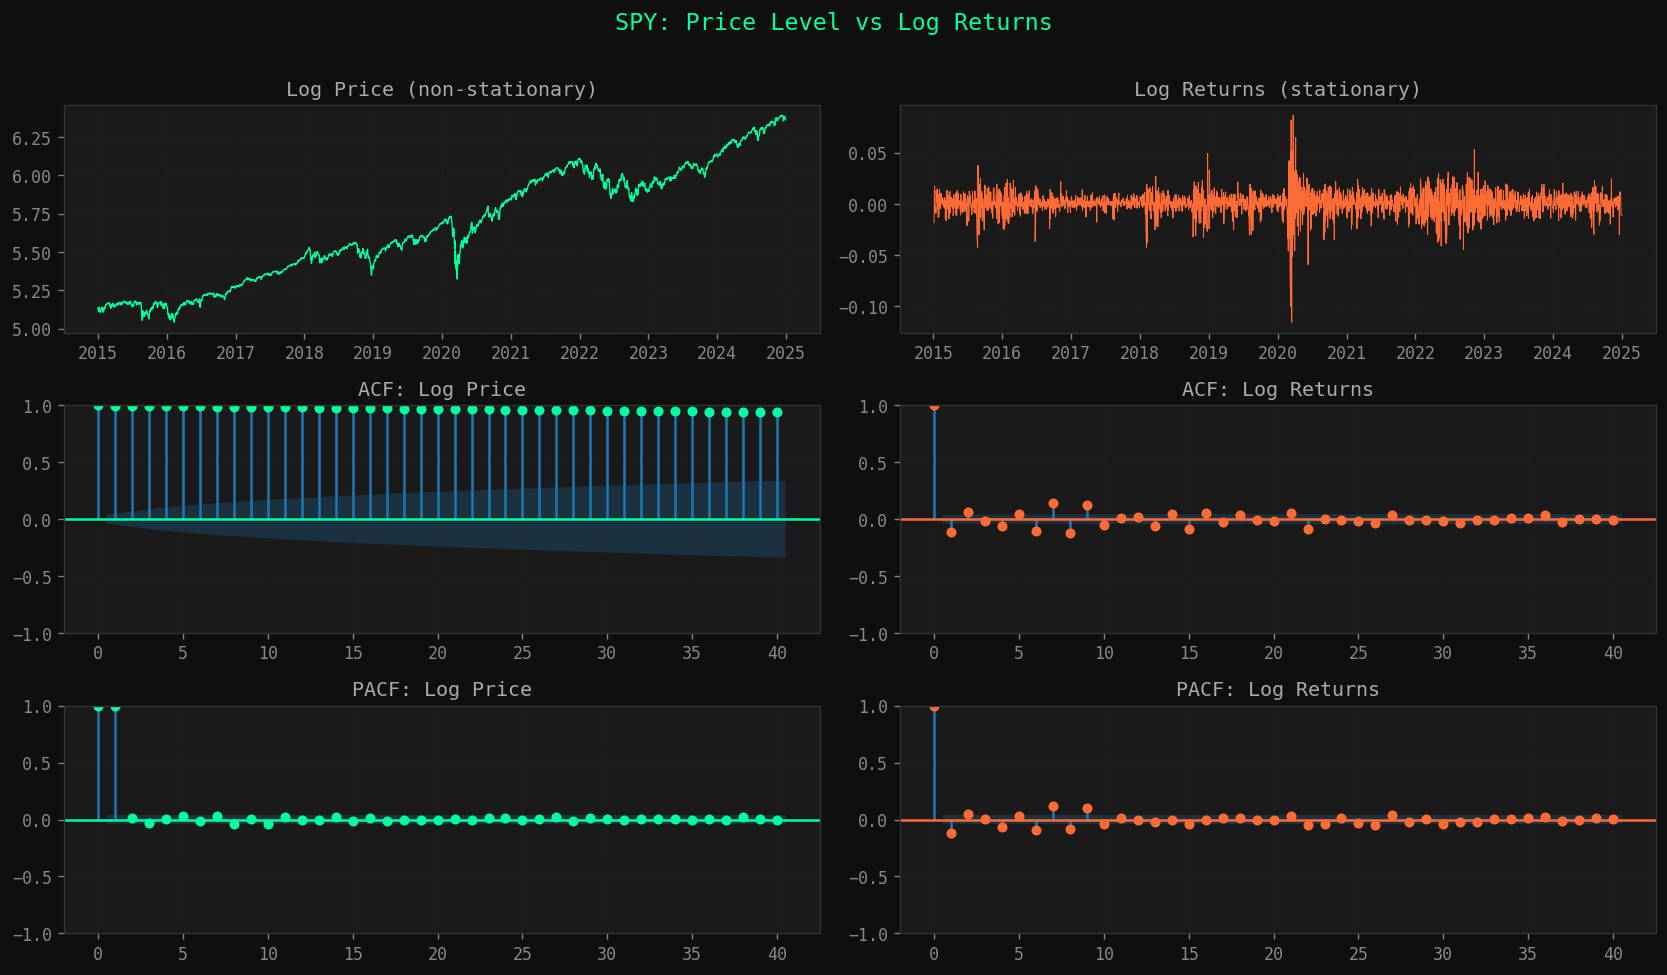


--- Log Price ---
ADF stat: -0.2146, p-value: 0.9368  --> NON-STATIONARY
KPSS stat: 7.9224, p-value: 0.0100 --> NON-STATIONARY

--- Log Returns ---
ADF stat: -15.7265, p-value: 0.0000  --> STATIONARY
KPSS stat: 0.0468, p-value: 0.1000 --> STATIONARY


In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 8))
fig.suptitle('SPY: Price Level vs Log Returns', fontsize=14, color=ACCENT, y=1.01)

axes[0,0].plot(log_prices, color=ACCENT, lw=0.8)
axes[0,0].set_title('Log Price (non-stationary)', color='#aaaaaa')

axes[0,1].plot(returns, color=ACCENT2, lw=0.6)
axes[0,1].set_title('Log Returns (stationary)', color='#aaaaaa')

plot_acf(log_prices, lags=40, ax=axes[1,0], color=ACCENT, alpha=0.05)
axes[1,0].set_title('ACF: Log Price', color='#aaaaaa')

plot_acf(returns, lags=40, ax=axes[1,1], color=ACCENT2, alpha=0.05)
axes[1,1].set_title('ACF: Log Returns', color='#aaaaaa')

plot_pacf(log_prices, lags=40, ax=axes[2,0], color=ACCENT, alpha=0.05)
axes[2,0].set_title('PACF: Log Price', color='#aaaaaa')
plot_pacf(returns, lags=40, ax=axes[2,1], color=ACCENT2, alpha=0.05)
axes[2,1].set_title('PACF: Log Returns', color='#aaaaaa')

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Stationarity tests
def stationarity_tests(series, name):
    print(f'\n--- {name} ---')
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(series.dropna())
    print(f'ADF stat: {adf_stat:.4f}, p-value: {adf_p:.4f}  --> {"STATIONARY" if adf_p < 0.05 else "NON-STATIONARY"}')
    kpss_stat, kpss_p, _, kpss_crit = kpss(series.dropna(), regression='c')
    print(f'KPSS stat: {kpss_stat:.4f}, p-value: {kpss_p:.4f} --> {"NON-STATIONARY" if kpss_p < 0.05 else "STATIONARY"}')

stationarity_tests(log_prices, 'Log Price')
stationarity_tests(returns, 'Log Returns')

### ACF and PACF: Log Prices vs Log Returns

#### Definitions

The **autocorrelation function** at lag $h$ is the raw correlation between 
the series and its lagged values:

$$\rho(h) = \text{Corr}(X_t, X_{t-h}) = \frac{\text{Cov}(X_t, X_{t-h})}{\text{Var}(X_t)} = \frac{\gamma(h)}{\gamma(0)}$$

The **partial autocorrelation function** at lag $h$ isolates the direct 
effect of lag $h$ after removing the linear influence of all intermediate 
lags $X_{t-1}, \ldots, X_{t-h+1}$:

$$\alpha(h) = \text{Corr}(X_t, X_{t-h} \mid X_{t-1}, \ldots, X_{t-h+1})$$

The word **partial** means the same thing as in partial derivatives: isolating 
the effect of one lag holding all intermediate lags fixed.

#### Confidence band

Both plots show a 95% confidence band under $H_0: \rho(h) = 0$:

$$\pm \frac{1.96}{\sqrt{T}}$$

Bars outside the band are statistically significant at the 5% level.

#### Results

| | Log Prices $\ln S_t$ | Log Returns $r_t$ |
|---|---|---|
| **ACF** | Decays very slowly, stays near 1 for many lags | Drops to zero immediately after lag 0 |
| **PACF** | Spikes at lag 1 ($\approx 1$), zero after | Drops to zero immediately after lag 0 |
| **Interpretation** | Non-stationary: unit root, random walk | Stationary: white noise, no autocorrelation |
| **Implication** | Must difference before modelling | Ready for ARMA/GARCH fitting |

#### Why each pattern arises

**Log prices**: under GBM $\ln S_t = \ln S_{t-1} + \varepsilon_t$ is a 
random walk, an AR(1) with $\phi = 1$. The ACF decays linearly as 
$\rho(h) \approx 1 - h/T$, the classic signature of a unit root. The PACF 
cuts off after lag 1 because once you condition on $\ln S_{t-1}$, no 
further history adds information.

**Log returns**: $r_t = \ln S_t - \ln S_{t-1} = \varepsilon_t$ under GBM, 
white noise by construction. Both ACF and PACF are zero at all lags $h > 0$, 
consistent with the weak form EMH: past returns contain no linear information 
about future returns.

----
**Stylized facts on return autocorrelation:**

- **Lag 1**: small negative autocorrelation for individual stocks due to 
  bid-ask bounce (Roll model). Small positive for indices due to 
  non-synchronous trading.
- **Lags $h > 1$**: no significant linear autocorrelation, consistent 
  with weak form EMH.
- **Squared returns** $r_t^2$: strongly positively autocorrelated at all 
  lags, the signature of volatility clustering (GARCH effects).

The absence of autocorrelation in returns but presence in squared returns 
is the central empirical fact motivating GARCH models.

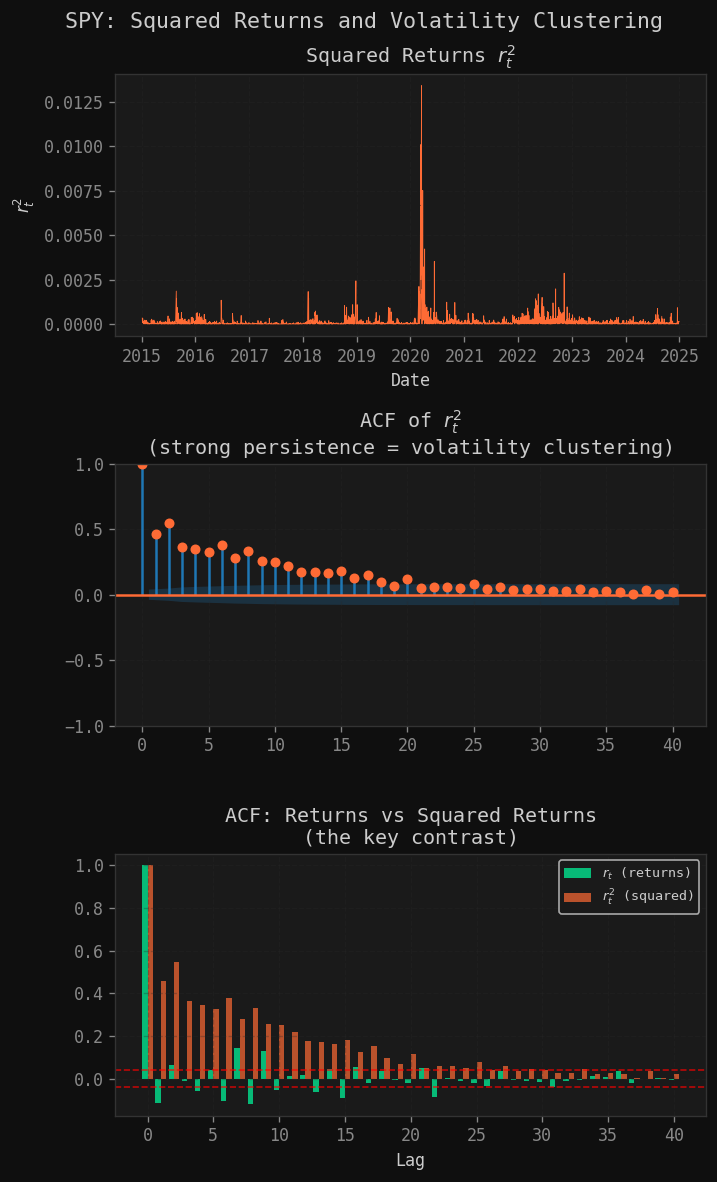

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(6, 10))
fig.suptitle('SPY: Squared Returns and Volatility Clustering', fontsize=13)

# Panel 1: squared returns over time
axes[0].plot(returns**2, color=ACCENT2, lw=0.5)
axes[0].set_title('Squared Returns $r_t^2$')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('$r_t^2$')
axes[0].grid(True, alpha=0.3)

# Panel 2: ACF of squared returns
plot_acf(returns**2, lags=40, ax=axes[1], color=ACCENT2, alpha=0.05)
axes[1].set_title('ACF of $r_t^2$\n(strong persistence = volatility clustering)')
axes[1].grid(True, alpha=0.3)

# Panel 3: ACF of returns vs squared returns overlaid
acf_ret  = acf(returns,    nlags=40)
acf_ret2 = acf(returns**2, nlags=40)
lags     = np.arange(41)
axes[2].bar(lags - 0.2, acf_ret,  width=0.4, color=ACCENT,  alpha=0.7, label='$r_t$ (returns)')
axes[2].bar(lags + 0.2, acf_ret2, width=0.4, color=ACCENT2, alpha=0.7, label='$r_t^2$ (squared)')
axes[2].axhline(1.96/np.sqrt(len(returns)),  color='red', lw=1, ls='--', alpha=0.7)
axes[2].axhline(-1.96/np.sqrt(len(returns)), color='red', lw=1, ls='--', alpha=0.7)
axes[2].set_title('ACF: Returns vs Squared Returns\n(the key contrast)')
axes[2].set_xlabel('Lag')
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

* Squared returns over time: the clustering is immediately visible, large values come in bursts around 2020 (Covid) and 2022 (rates)
* ACF of squared returns: bars stay significant for many lags, the slow decay is the signature of volatility persistence
* Returns vs squared returns side by side: the key contrast:
    - returns have no significant autocorrelation
    - squared returns do at almost every lag, motivating GARCH

---
## Part 2: White Noise

### Definition

A process $\{\varepsilon_t\}$ is **white noise** if:

$$\mathbb{E}[\varepsilon_t] = 0, \quad \mathbb{E}[\varepsilon_t^2] = \sigma^2, \quad \mathbb{E}[\varepsilon_t \varepsilon_s] = 0 \text{ for } t \neq s$$

### Autocovariance function

$$\gamma(h) = \begin{cases} \sigma^2 & h = 0 \\ 0 & h \neq 0 \end{cases}, \qquad \rho(h) = \begin{cases} 1 & h = 0 \\ 0 & h \neq 0 \end{cases}$$

### Finance application: Efficient Market Hypothesis

Under the **weak form EMH**, log returns should be white noise: past prices contain no information about future returns. If $\rho(h) \neq 0$ for some $h > 0$, there is a linear predictable component, which is a potential anomaly.

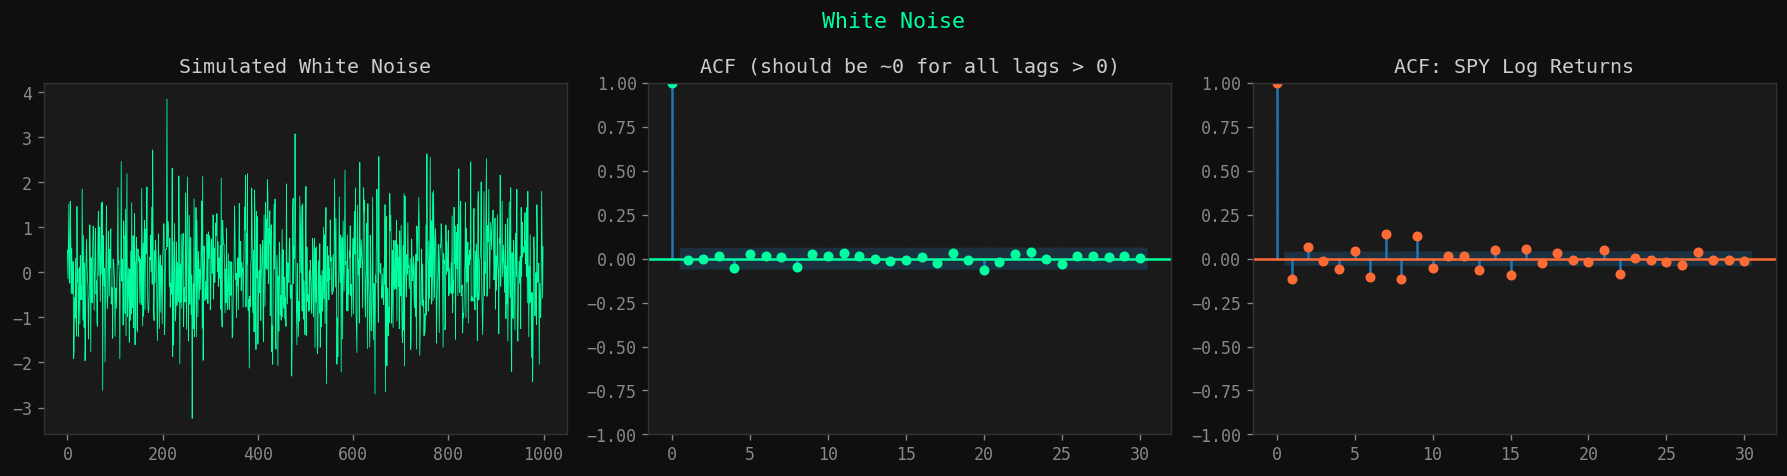

SPY returns look close to white noise in levels -- consistent with weak-form EMH.
But check squared returns for volatility clustering (Part 6).


In [4]:
np.random.seed(42)
T = 1000
wn = np.random.normal(0, 1, T)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('White Noise', fontsize=13, color=ACCENT)

axes[0].plot(wn, color=ACCENT, lw=0.5)
axes[0].set_title('Simulated White Noise')

plot_acf(wn, lags=30, ax=axes[1], color=ACCENT)
axes[1].set_title('ACF (should be ~0 for all lags > 0)')

# SPY returns: are they white noise?
plot_acf(returns, lags=30, ax=axes[2], color=ACCENT2)
axes[2].set_title('ACF: SPY Log Returns')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('SPY returns look close to white noise in levels -- consistent with weak-form EMH.')
print('But check squared returns for volatility clustering (Part 6).')

---
## Part 3: AR(p) — Autoregressive Process

### Definition

$$X_t = c + \phi_1 X_{t-1} + \phi_2 X_{t-2} + \cdots + \phi_p X_{t-p} + \varepsilon_t, \quad \varepsilon_t \sim WN(0, \sigma^2)$$


### Stationarity condition

Using the lag operator $L$ where $LX_t = X_{t-1}$, the AR(p) can be written as:

$$(1 - \phi_1 L - \phi_2 L^2 - \cdots - \phi_p L^p) X_t = c + \varepsilon_t$$

The expression in parentheses is the **characteristic polynomial** in $L$. 
Treating $L$ as a variable $z$, the characteristic equation is:

$$1 - \phi_1 z - \phi_2 z^2 - \cdots - \phi_p z^p = 0$$

This polynomial has $p$ roots $z_1, \ldots, z_p$. Note that the roots are 
the $z$ values, not the $\phi$ coefficients. The $\phi$'s are the parameters 
of the model; the $z$'s are what you solve for. Stationarity requires all 
roots to lie **outside** the unit circle $|z_i| > 1$, equivalently the 
corresponding $|\phi_i| < 1$ for AR(1). The three cases are:

| Root | Process | Behavior |
|------|---------|----------|
| $\|z_i\| > 1$ | Stationary | Shocks decay, mean reversion |
| $\|z_i\| = 1$ | Unit root | Shocks permanent, random walk |
| $\|z_i\| < 1$ | Explosive | Shocks amplified, diverges |


Once again: All roots of the characteristic polynomial $1 - \phi_1 z - \cdots - \phi_p z^p = 0$ must lie **outside** the unit circle.



### Moments of AR(1): 

for the AR(1) series:

$$X_t = c + \phi X_{t-1} + \varepsilon_t$$

The moments (mean, variance and autocorrelation) results are obtained taking expectations and using stationarity assumptions.

$$\mathbb{E}[X_t] = \mu = \frac{c}{1-\phi}, \quad |\phi| < 1$$

$$\text{Var}(X_t) = \gamma(0) = \frac{\sigma^2}{1 - \phi^2}$$

$$\gamma(h) = \phi^h \cdot \gamma(0), \qquad \rho(h) = \phi^h$$

The ACF decays exponentially at rate $\phi^h$. The PACF cuts off after 
lag 1: once you control for $X_{t-1}$, no further lag adds information.



---

### Finance application: mean-reverting spread (pairs trading)

#### Cointegration

Two stocks $A$ and $B$ are **cointegrated** if each price series is 
non-stationary (random walk) individually, but a linear combination of 
their log prices (a spread) is stationary:

$$Z_t = \ln A_t - \beta \ln B_t \sim \text{stationary}$$

The coefficient $\beta$ is the **cointegrating vector**, estimated by OLS. 
Economically, cointegration means the two stocks share a common long-run 
equilibrium: they may drift apart temporarily but are pulled back together 
over time. Classic examples are:

- two stocks in the same sector (Coca-Cola and Pepsi)
- a stock and its ADR listed on two exchanges
- crude oil and gasoline (related by refining economics)

#### Why mean reversion follows from cointegration

If $Z_t$ is stationary it must mean revert to its long-run mean $\mu$. 
The AR(1) model formalizes this:

$$Z_t = c + \phi Z_{t-1} + \varepsilon_t, \quad 0 < \phi < 1$$

The closer $\phi$ is to 1 the slower the mean reversion. The closer to 0 
the faster. You do not assume mean reversion arbitrarily: you **test** for 
it first using the ADF test on $Z_t$. If ADF rejects the unit root, $Z_t$ 
is stationary and the AR(1) mean reversion model is justified.

The **half-life** of mean reversion tells you how many days it takes for 
a deviation from $\mu$ to shrink by half on average:

$$h_{1/2} = -\frac{\ln 2}{\ln \phi}$$

For example if $\phi = 0.95$ the half-life is $-\ln 2 / \ln 0.95 \approx 13$ 
days: a shock to the spread takes 13 days to halve. This is important 
for sizing the trade: a very slow mean reversion means capital is tied 
up for a long time.

#### The trading signal

The long-run mean of the spread is $\mu = c/(1-\phi)$. The trading signal 
is how many standard deviations $Z_t$ is away from $\mu$:

$$\text{signal}_t = \frac{Z_t - \mu}{\sigma_Z}$$

where $\sigma_Z = \sqrt{\gamma(0)} = \sigma/\sqrt{1-\phi^2}$ is the 
unconditional standard deviation of the spread. The trading



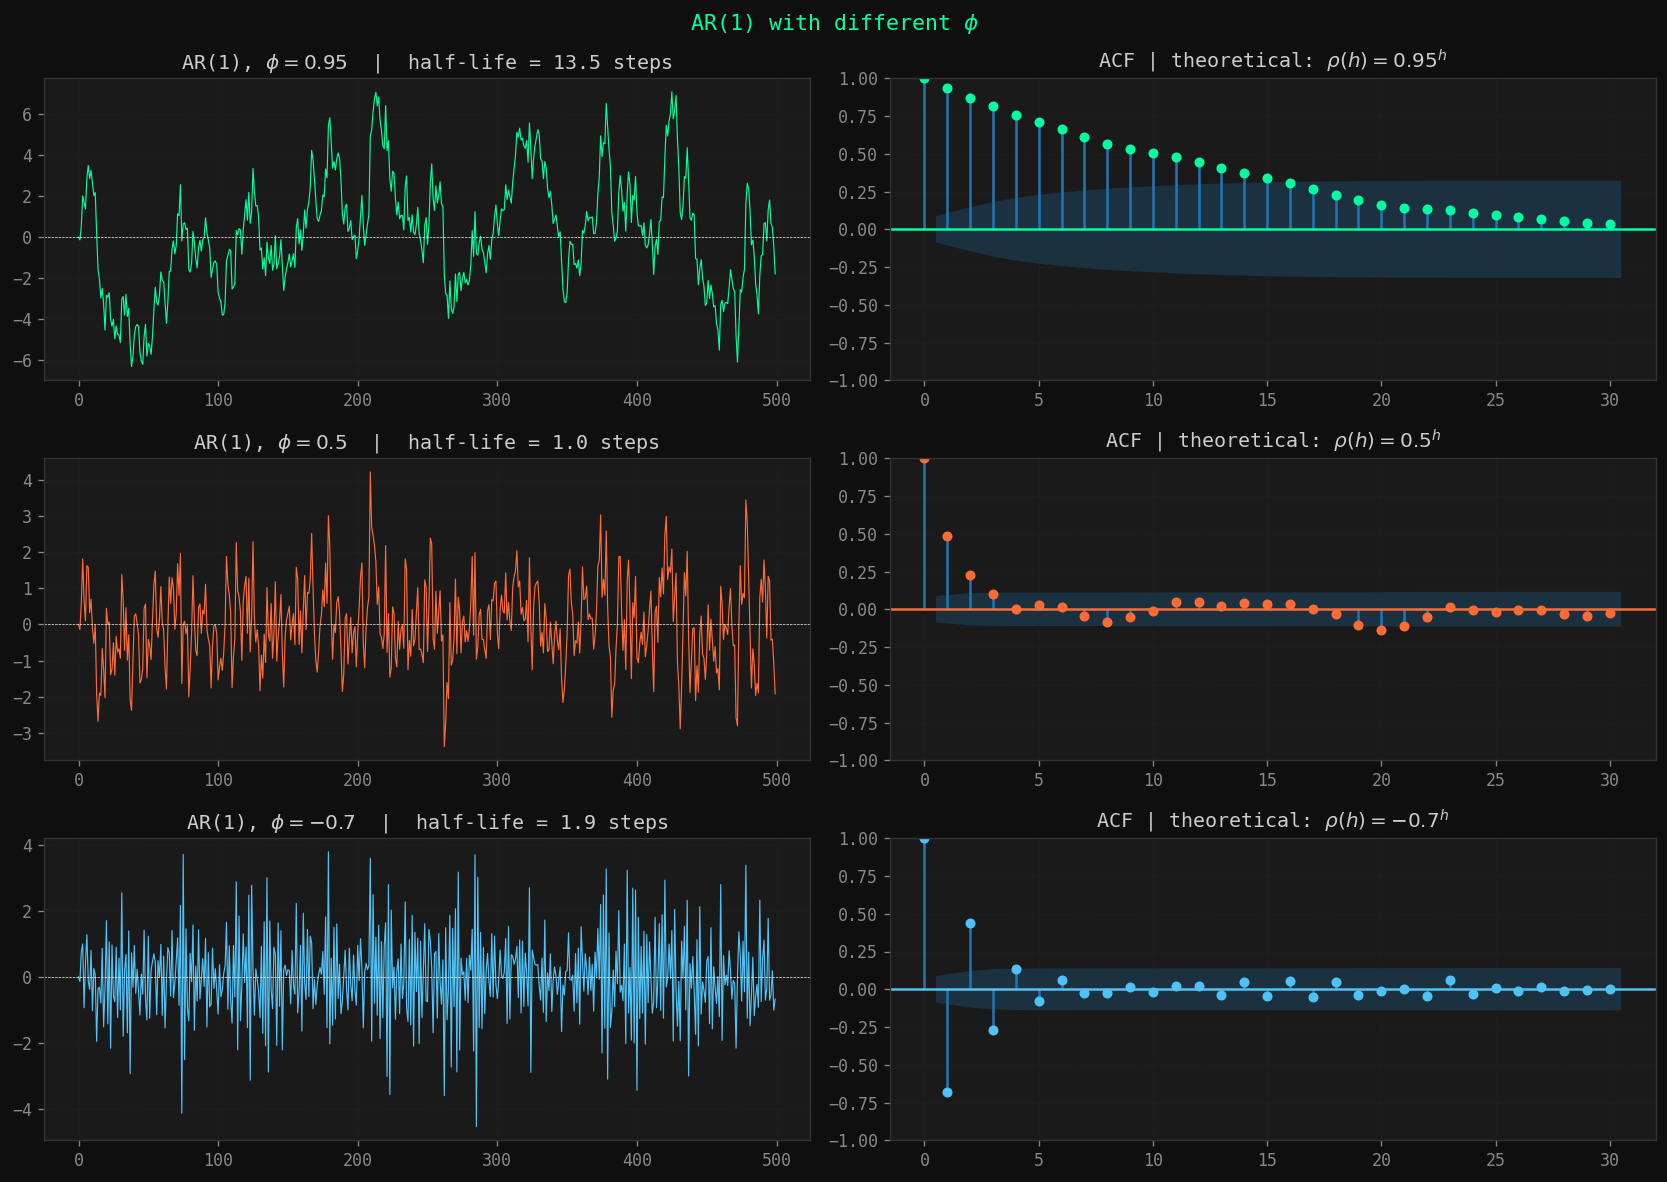

In [5]:
# Simulate AR(1) with different phi
def simulate_ar1(phi, c=0, sigma=1, T=500, seed=42):
    np.random.seed(seed)
    X = np.zeros(T)
    eps = np.random.normal(0, sigma, T)
    for t in range(1, T):
        X[t] = c + phi * X[t-1] + eps[t]
    return X

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('AR(1) with different $\\phi$', fontsize=13, color=ACCENT)

params = [0.95, 0.5, -0.7]
colors = [ACCENT, ACCENT2, ACCENT3]

for i, (phi, col) in enumerate(zip(params, colors)):
    X = simulate_ar1(phi)
    axes[i,0].plot(X, color=col, lw=0.7)
    axes[i,0].set_title(f'AR(1), $\\phi={phi}$  |  half-life = {-np.log(2)/np.log(abs(phi)):.1f} steps')
    axes[i,0].axhline(0, color='white', lw=0.4, ls='--')
    plot_acf(X, lags=30, ax=axes[i,1], color=col, alpha=0.05)
    axes[i,1].set_title(f'ACF | theoretical: $\\rho(h) = {phi}^h$')

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Gold / Silver pair trading

GLD: SPDR Gold Shares, tracks the price of gold
SLV: iShares Silver Trust, tracks the price of silver

They are a natural pair for cointegration because gold and silver are both precious metals driven by many of the same macroeconomic factors: 
* inflation expectations
* real interest rates
* dollar strength
* safe haven demand. 

Their prices tend to move together over the long run even though they can diverge significantly in the short run, making the spread a classic pairs trading candidate.
The gold/silver ratio is widely watched by commodity traders as a measure of relative value between the two metals.

In [12]:
# Pairs trading: GLD vs SLV spread
data = yf.download(['GLD', 'SLV'], start='2018-01-01', end='2026-05-13', auto_adjust=True)['Close']
data = data.dropna()

log_gld = np.log(data['GLD']) 
log_slv = np.log(data['SLV'])

[*********************100%***********************]  2 of 2 completed


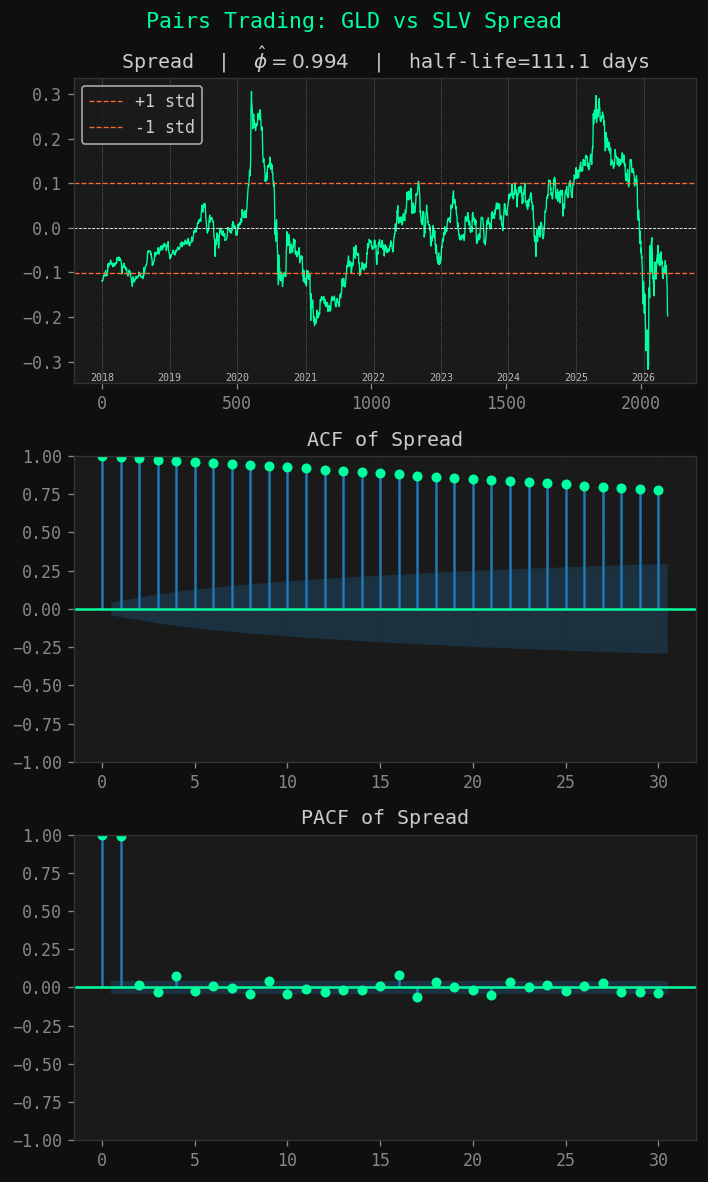

AR(1) fit: phi = 0.9938, half-life = 111.1 trading days
ADF on spread: p = 0.0779


In [13]:
# OLS beta
from numpy.polynomial import polynomial as P
beta = P.polyfit(log_slv, log_gld, 1)[1]
spread = log_gld - beta * log_slv
spread = spread - spread.mean()

# Fit AR(1) to spread
model = ARIMA(spread, order=(1,0,0)).fit()
phi_hat = model.params['ar.L1']
half_life = -np.log(2) / np.log(abs(phi_hat))

fig, axes = plt.subplots(3, 1, figsize=(6, 10))
fig.suptitle('Pairs Trading: GLD vs SLV Spread', fontsize=13, color=ACCENT)

# year change vertical lines
year_changes = spread.index[spread.index.year != pd.Series(spread.index.year).shift(1).values]

axes[0].plot(spread.values, color=ACCENT, lw=0.8)
axes[0].axhline(0, color='white', lw=0.5, ls='--')
axes[0].axhline(spread.std(),  color=ACCENT2, lw=0.8, ls='--', label='+1 std')
axes[0].axhline(-spread.std(), color=ACCENT2, lw=0.8, ls='--', label='-1 std')
axes[0].set_title(f'Spread  |  $\\hat{{\\phi}}={phi_hat:.3f}$  |  half-life={half_life:.1f} days')
axes[0].legend()

# add year labels on x axis of panel 0
for date in year_changes:
    idx = spread.index.get_loc(date)
    axes[0].axvline(idx, color='white', lw=0.4, ls=':', alpha=0.5)
    axes[0].text(idx, axes[0].get_ylim()[0], str(date.year),
                 color='white', fontsize=6, alpha=0.7,
                 ha='center', va='bottom')

plot_acf(spread,  lags=30, ax=axes[1], color=ACCENT)
axes[1].set_title('ACF of Spread')

plot_pacf(spread, lags=30, ax=axes[2], color=ACCENT)
axes[2].set_title('PACF of Spread')

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f'AR(1) fit: phi = {phi_hat:.4f}, half-life = {half_life:.1f} trading days')
print(f'ADF on spread: p = {adfuller(spread)[1]:.4f}')

---
## Part 4: MA(q) — Moving Average Process

### Definition

$$X_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \cdots + \theta_q \varepsilon_{t-q}, \quad \varepsilon_t \sim WN(0, \sigma^2)$$

### Moments of MA(1): 

$$X_t = \varepsilon_t + \theta \varepsilon_{t-1}$$

$$\mathbb{E}[X_t] = 0$$

$$\gamma(0) = \sigma^2(1 + \theta^2), \quad \gamma(1) = \sigma^2 \theta, \quad \gamma(h) = 0 \text{ for } h > 1$$

$$\rho(1) = \frac{\theta}{1+\theta^2}, \qquad \rho(h) = 0 \text{ for } h > q$$

The ACF **cuts off** after lag $q$. The PACF decays exponentially. This is the key identification rule.



### Invertibility condition

All roots of $1 + \theta_1 z + \cdots + \theta_q z^q = 0$ must lie outside the unit circle. Invertibility ensures the MA can be written as an infinite AR, which is needed for forecasting.


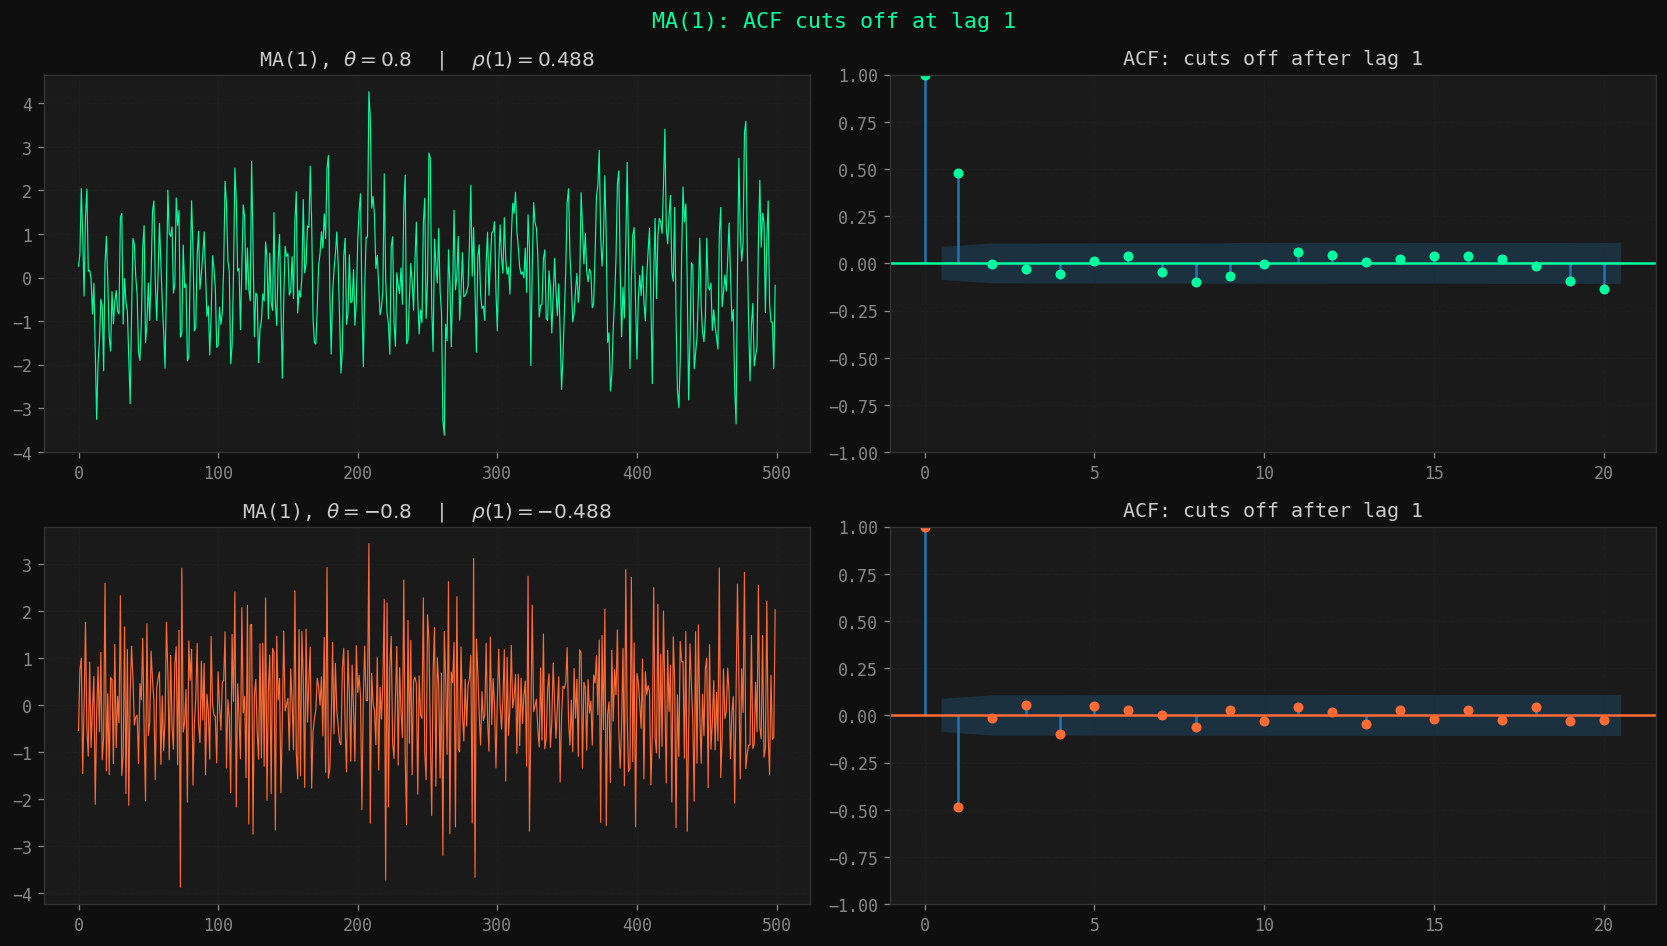

In [ ]:
def simulate_ma1(theta, sigma=1, T=500, seed=42):
    np.random.seed(seed)
    eps = np.random.normal(0, sigma, T+1) # white noise vector: need T+1 epsilons to generate T MA(1) values
    return np.array([eps[t] + theta * eps[t-1] for t in range(1, T+1)])

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('MA(1): ACF cuts off at lag 1', fontsize=13, color=ACCENT)

for i, (theta, col) in enumerate(zip([0.8, -0.8], [ACCENT, ACCENT2])):
    X = simulate_ma1(theta)
    rho_theoretical = theta / (1 + theta**2)
    axes[i,0].plot(X, color=col, lw=0.7)
    axes[i,0].set_title(f'MA(1), $\\theta={theta}$  |  $\\rho(1)={rho_theoretical:.3f}$')
    plot_acf(X, lags=20, ax=axes[i,1], color=col, alpha=0.05)
    axes[i,1].set_title('ACF: cuts off after lag 1')

for ax in axes.flat:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Finance application: bid-ask bounce and the Roll model

In market microstructure, every transaction occurs either at the **ask** 
(buyer initiated) or the **bid** (seller initiated). Let $c$ be the 
half-spread: the distance from the midprice to the bid or ask. The 
**Roll (1984)** model says that observed transaction price changes follow:

$$\Delta P_t = c \cdot Q_t - c \cdot Q_{t-1} + u_t$$

where $Q_t \in \{-1, +1\}$ is the trade direction ($+1$ for a buy, $-1$ 
for a sell) and $u_t \sim WN(0, \sigma_u^2)$ captures fundamental price 
innovations. This is an MA(1) with $\theta = -1$ in the error structure: 
a buy followed by a sell generates a negative price change, creating 
negative first-order autocorrelation in $\Delta P_t$.

**Note on the white noise assumption.** $Q_t \in \{-1, +1\}$ is not 
Gaussian: it is a symmetric Bernoulli variable. However it satisfies 
the weak white noise conditions:

$$\mathbb{E}[Q_t] = 0, \quad \text{Var}(Q_t) = 1, \quad 
\mathbb{E}[Q_t Q_s] = 0 \text{ for } t \neq s$$

White noise does not require normality. It only requires zero mean, 
constant variance, and no serial correlation. $Q_t$ satisfies all three.

The half-spread $c$ can be recovered directly from the autocovariance 
of price changes without fitting any model:

$$\hat{c} = \sqrt{-\text{Cov}(\Delta P_t, \Delta P_{t-1})}$$

since $\gamma(1) = -c^2$ in the Roll model. The negative sign is the 
key: the bid-ask bounce mechanically generates negative lag-1 
autocorrelation in transaction price changes, which is the most 
robust stylized fact in market microstructure.

True half-spread c     : 0.0500
Roll estimator c_hat   : 0.0507
Implied full spread    : 0.1015

MA(1) theta estimate   : -0.6815
MA(1) sigma estimate   : 0.0606
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2000
Model:                 ARIMA(0, 0, 1)   Log Likelihood                2767.948
Date:                Thu, 14 May 2026   AIC                          -5529.896
Time:                        23:33:46   BIC                          -5513.094
Sample:                             0   HQIC                         -5523.727
                               - 2000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009      0.000      2.168     

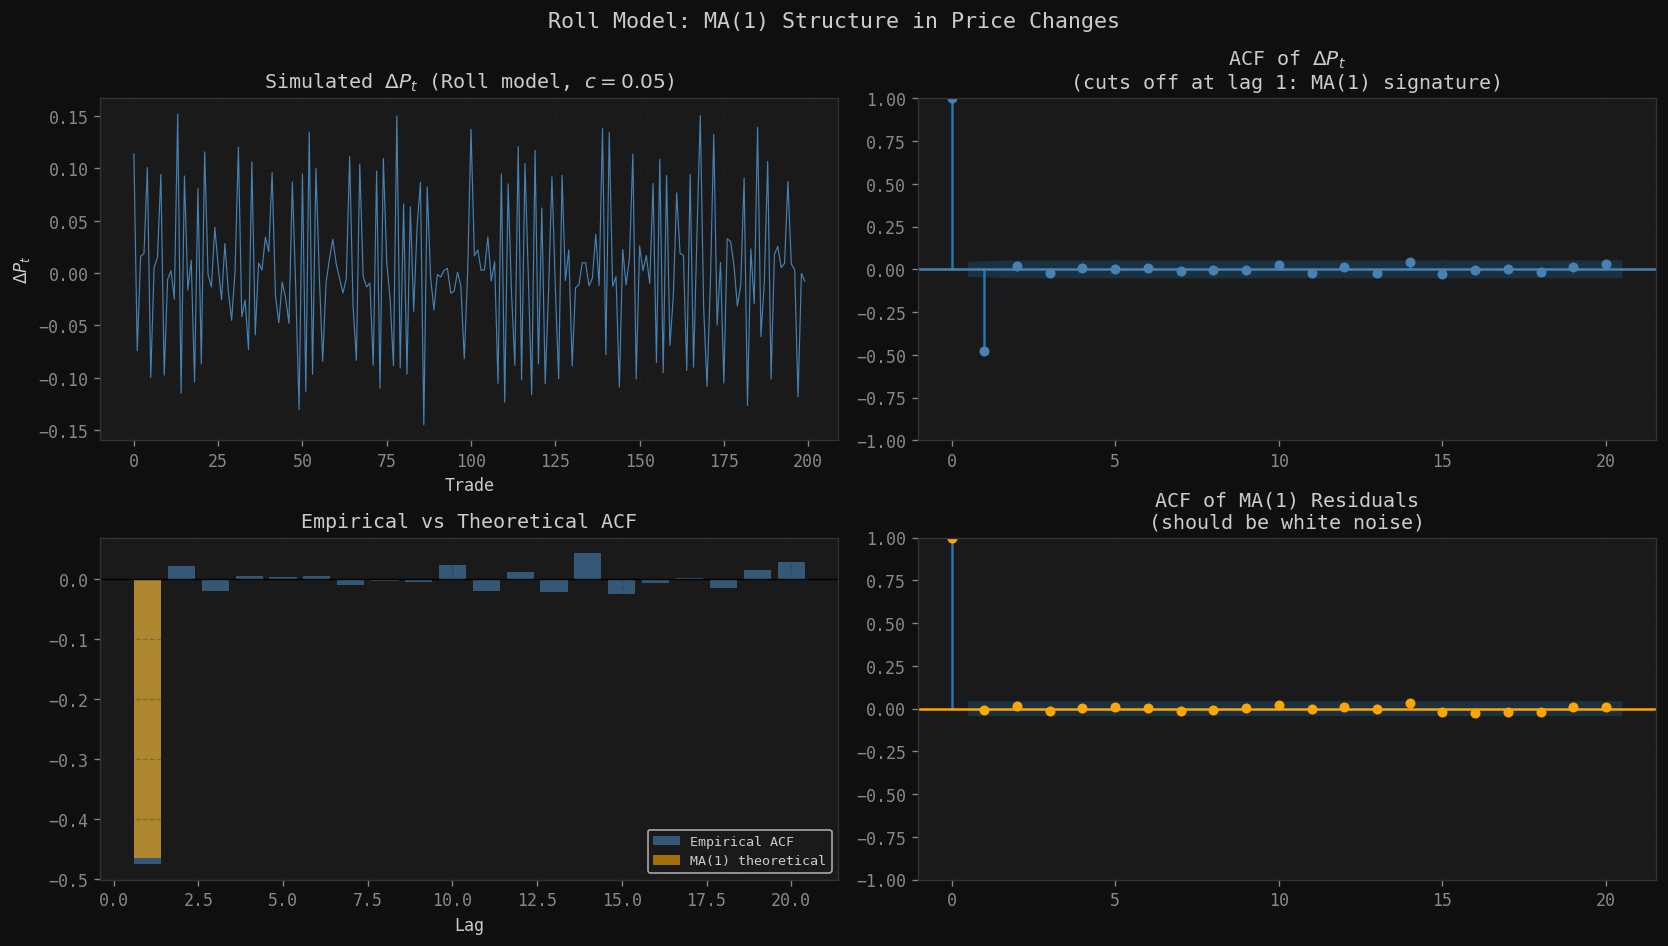

In [2]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

def simulate_roll_model(c=0.05, T=1000, seed=42):
    """
    Simulate Roll model: delta_P = c*Q_t - c*Q_{t-1} + u_t
    Q_t in {-1, +1}, u_t ~ N(0, sigma_u^2)
    """
    np.random.seed(seed)
    Q   = np.random.choice([-1, 1], size=T+1)  # trade direction
    u   = np.random.normal(0, 0.02, T)         # noise
    dP  = c*Q[1:] - c*Q[:-1] + u               # price changes: MA(1) structure
    return dP, Q

# Simulate
c_true = 0.05
dP, Q  = simulate_roll_model(c=c_true, T=2000)

# Roll estimator of c
gamma1 = np.cov(dP[1:], dP[:-1])[0,1]
c_roll = np.sqrt(max(-gamma1, 0))

print(f'True half-spread c     : {c_true:.4f}')
print(f'Roll estimator c_hat   : {c_roll:.4f}')
print(f'Implied full spread    : {2*c_roll:.4f}')

# Fit MA(1) via ARIMA(0,0,1)
ma1_model = ARIMA(dP, order=(0,0,1)).fit()
theta_hat = ma1_model.maparams[0]
print(f'\nMA(1) theta estimate   : {theta_hat:.4f}')
print(f'MA(1) sigma estimate   : {np.sqrt(ma1_model._params_variance[0]):.4f}')
print(ma1_model.summary())

# Recover c from theta
# In Roll model: rho(1) = -c^2 / (2c^2 + sigma_u^2)
# theta/(1+theta^2) = rho(1), so c^2 = -gamma(1)
gamma0_hat = dP.var()
gamma1_hat = np.cov(dP[1:], dP[:-1])[0,1]
c_from_theta = np.sqrt(max(-gamma1_hat, 0))
print(f'c recovered from gamma : {c_from_theta:.4f}')

# Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('Roll Model: MA(1) Structure in Price Changes', fontsize=13)

# Panel 1: simulated price changes
axes[0,0].plot(dP[:200], color='steelblue', lw=0.7)
axes[0,0].set_title(f'Simulated $\\Delta P_t$ (Roll model, $c={c_true}$)')
axes[0,0].set_xlabel('Trade')
axes[0,0].set_ylabel('$\\Delta P_t$')
axes[0,0].grid(True, alpha=0.3)

# Panel 2: ACF of price changes (should cut off after lag 1)
plot_acf(dP, lags=20, ax=axes[0,1], color='steelblue', alpha=0.05)
axes[0,1].set_title('ACF of $\\Delta P_t$\n(cuts off at lag 1: MA(1) signature)')
axes[0,1].grid(True, alpha=0.3)

# Panel 3: fitted vs actual ACF
acf_actual    = [np.corrcoef(dP[h:], dP[:-h])[0,1] for h in range(1, 21)]
rho1_theoretical = theta_hat / (1 + theta_hat**2)
acf_theoretical  = [rho1_theoretical if h == 1 else 0 for h in range(1, 21)]

axes[1,0].bar(range(1, 21), acf_actual,      color='steelblue', alpha=0.6, label='Empirical ACF')
axes[1,0].bar(range(1, 21), acf_theoretical, color='orange',    alpha=0.6, label='MA(1) theoretical')
axes[1,0].axhline(0, color='black', lw=0.8)
axes[1,0].set_title('Empirical vs Theoretical ACF')
axes[1,0].set_xlabel('Lag')
axes[1,0].legend(fontsize=8)
axes[1,0].grid(True, alpha=0.3)

# Panel 4: residuals of fitted MA(1)
residuals = ma1_model.resid
plot_acf(residuals, lags=20, ax=axes[1,1], color='orange', alpha=0.05)
axes[1,1].set_title('ACF of MA(1) Residuals\n(should be white noise)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The example below recovers the order of the model automatically using auro_arima

In [5]:
from pmdarima import auto_arima

# automatic order selection
auto_model = auto_arima(
    dP,
    d=0,              # no differencing, dP already stationary
    max_p=5, max_q=5,
    seasonal=False,
    information_criterion='aic',
    stepwise=True,
    trace=True,
    suppress_warnings=True
)

print(f'\nauto_arima selected order: ARMA{auto_model.order}')

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-5521.905, Time=0.22 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-4759.796, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-5268.717, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-5527.226, Time=0.07 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-5525.493, Time=0.08 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=-5525.485, Time=0.12 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-5523.824, Time=0.10 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-5529.896, Time=0.07 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-4758.136, Time=0.04 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-5528.069, Time=0.28 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=-5528.062, Time=0.23 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-5267.636, Time=0.04 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=-5526.418, Time=0.22 sec

Best model:  ARIMA(0,0,1)(0,0,0)[0] intercept
Total fit time: 1.556 seconds

auto_ari

Then, once identified, fit model to find theta.

In [6]:
# then fit the confirmed order manually for full statsmodels output
ma1_model = ARIMA(dP, order=auto_model.order).fit()
theta_hat = ma1_model.maparams[0]
print(f'MA(1) theta : {theta_hat:.4f}')

MA(1) theta : -0.6815


---
## Part 5: ARMA(p,q)

### Definition

$$X_t = c + \sum_{i=1}^p \phi_i X_{t-i} + \varepsilon_t + \sum_{j=1}^q \theta_j \varepsilon_{t-j}$$

### Moments

$$\mathbb{E}[X_t] = \mu = \frac{c}{1 - \phi_1 - \cdots - \phi_p}$$

The autocovariance function satisfies the **Yule-Walker equations** for $h > q$:

$$\gamma(h) = \phi_1 \gamma(h-1) + \cdots + \phi_p \gamma(h-p), \quad h > q$$

For $h \leq q$ there are additional MA contributions.

### Identification via ACF and PACF

<small> 

| Process | ACF | PACF |
|---|---|---|
| AR(p) | decays exponentially | cuts off at lag $p$ |
| MA(q) | cuts off at lag $q$ | decays exponentially |
| ARMA(p,q) | decays exponentially | decays exponentially |

</small> 

In practice, use **AIC/BIC** to select $p$ and $q$ rather than relying solely on visual inspection.

### Finance application: earnings and macro forecasting

[*********************100%***********************]  1 of 1 completed


ADF p-value on VIX level: 0.0000 --> STATIONARY


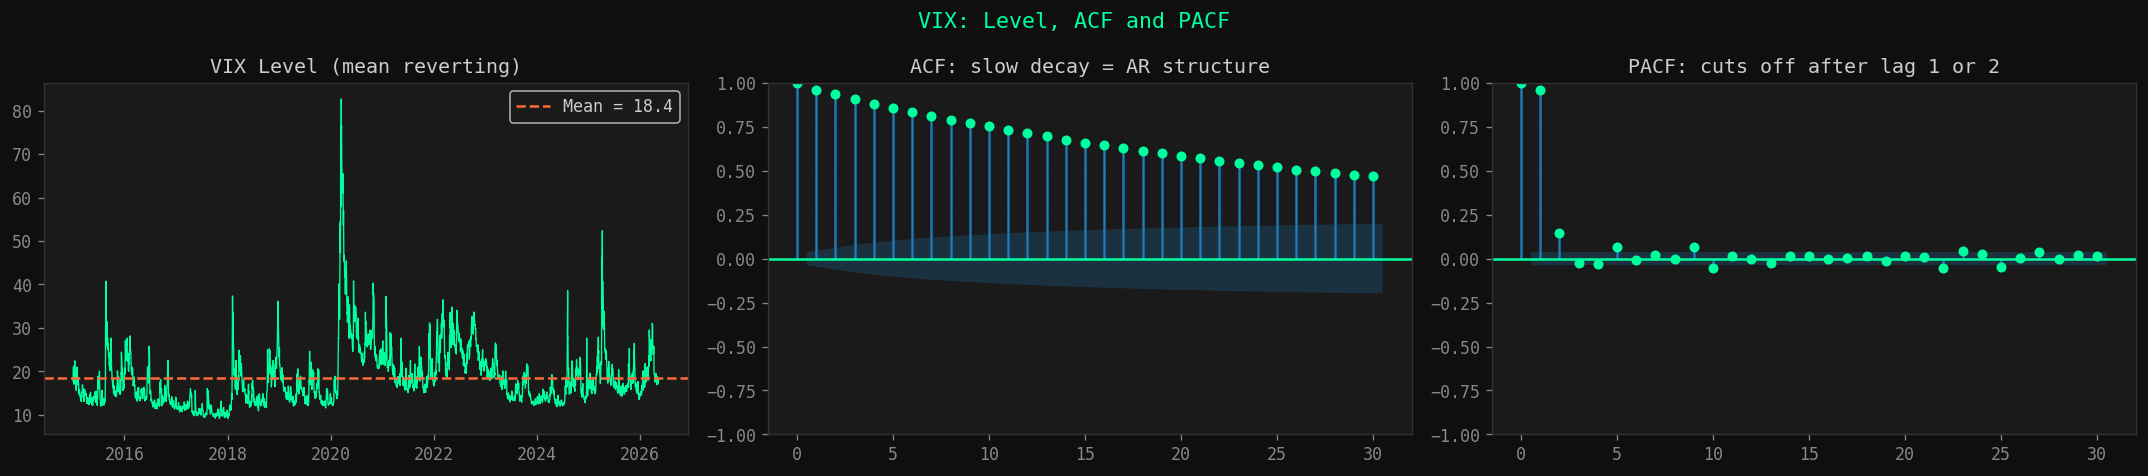

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=11843.904, Time=0.33 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=25130.466, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=21566.753, Time=0.05 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=11842.088, Time=0.04 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=19147.478, Time=0.13 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=11843.644, Time=0.04 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=11843.095, Time=0.07 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=17375.572, Time=0.22 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=11842.273, Time=0.07 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=11834.026, Time=0.50 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=inf, Time=0.59 sec
 ARIMA(2,0,4)(0,0,0)[0]             : AIC=11823.200, Time=0.40 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=11827.008, Time=0.08 sec
 ARIMA(3,0,4)(0,0,0)[0]        

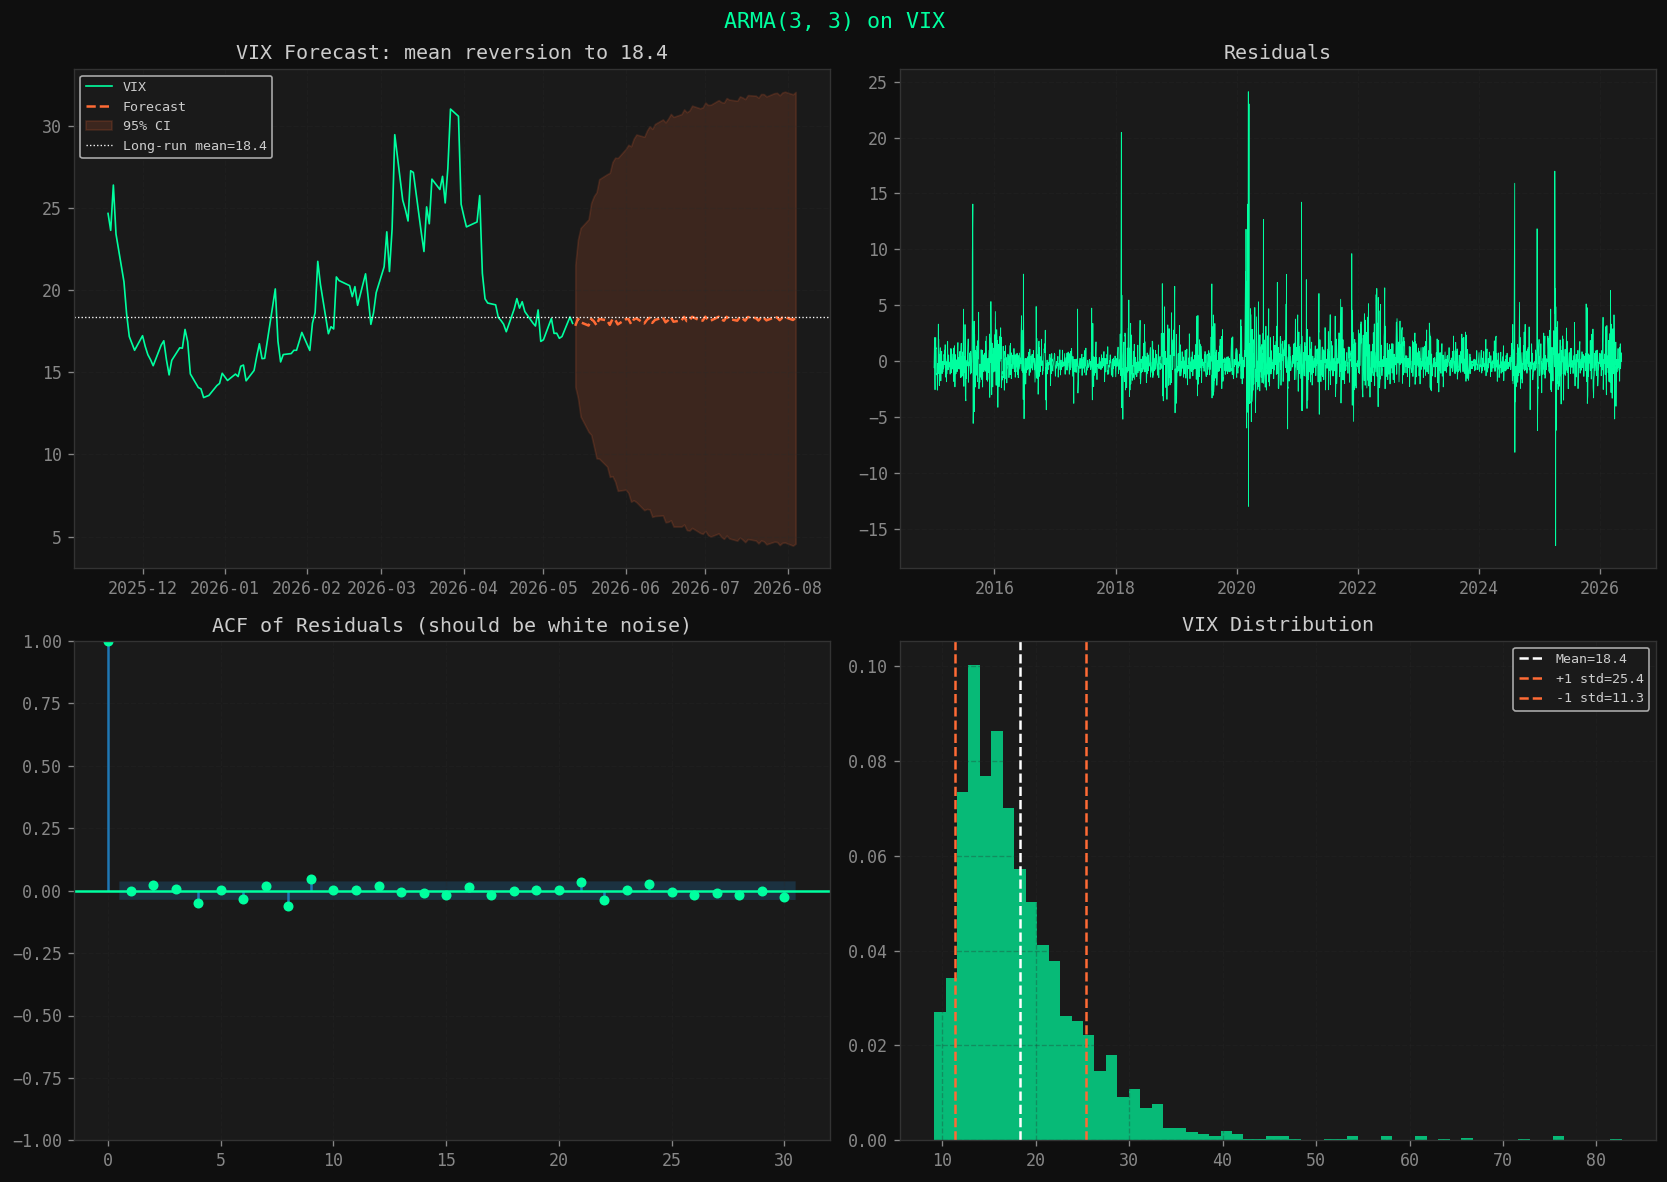

                               SARIMAX Results                                
Dep. Variable:                   ^VIX   No. Observations:                 2856
Model:                 ARIMA(3, 0, 3)   Log Likelihood               -5883.504
Date:                Fri, 15 May 2026   AIC                          11783.008
Time:                        00:02:04   BIC                          11830.665
Sample:                             0   HQIC                         11800.193
                               - 2856                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.3680      1.535     11.962      0.000      15.359      21.378
ar.L1          0.0751      0.009      8.401      0.000       0.058       0.093
ar.L2         -0.0991      0.007    -14.803      0.0

In [ ]:
# Download VIX
vix = yf.download('^VIX', start='2015-01-01', end='2026-05-13',
                   auto_adjust=True)['Close'].squeeze().dropna()

# stationarity test
adf_p = adfuller(vix)[1]
print(f'ADF p-value on VIX level: {adf_p:.4f} --> {"STATIONARY" if adf_p < 0.05 else "NON-STATIONARY"}')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle('VIX: Level, ACF and PACF', fontsize=13, color=ACCENT)

axes[0].plot(vix, color=ACCENT, lw=0.8)
axes[0].axhline(vix.mean(), color=ACCENT2, lw=1.5, ls='--', 
                label=f'Mean = {vix.mean():.1f}')
axes[0].set_title('VIX Level (mean reverting)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

plot_acf(vix,  lags=30, ax=axes[1], color=ACCENT)
axes[1].set_title('ACF: slow decay = AR structure')
axes[1].grid(True, alpha=0.3)

plot_pacf(vix, lags=30, ax=axes[2], color=ACCENT)
axes[2].set_title('PACF: cuts off after lag 1 or 2')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# auto_arima on VIX level

auto_model = auto_arima(
    vix,
    d=0,
    max_p=5, max_q=5,
    seasonal=False,
    information_criterion='aic',
    stepwise=True,
    trace=True,
    suppress_warnings=True
)

print(f'\nauto_arima selected: ARMA{auto_model.order}')

# refit with statsmodels
best_order = auto_model.order
best_model = ARIMA(vix, order=best_order).fit()
phi_hat    = best_model.arparams[0] if best_model.arparams.size > 0 else None
mu_hat     = best_model.params.iloc[0] / (1 - best_model.arparams.sum()) \
             if best_model.arparams.size > 0 else vix.mean()

print(f'AIC          : {best_model.aic:.2f}')
if phi_hat is not None:
    half_life = -np.log(2) / np.log(abs(phi_hat))
    print(f'AR(1) phi    : {phi_hat:.4f}')
    print(f'Half-life    : {half_life:.1f} days')
    print(f'Long-run mean: {mu_hat:.2f}')

# forecast 60 days ahead
fc        = best_model.forecast(steps=60)
conf      = best_model.get_forecast(steps=60).conf_int()
fc_index  = pd.date_range(vix.index[-1], periods=61, freq='B')[1:]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'ARMA{best_order[:1] + best_order[2:]} on VIX', 
             fontsize=13, color=ACCENT)

# Panel 1: VIX with forecast
axes[0,0].plot(vix.iloc[-120:], color=ACCENT, lw=1, label='VIX')
axes[0,0].plot(fc_index, fc.values, color=ACCENT2, lw=1.5, 
               ls='--', label='Forecast')
axes[0,0].fill_between(fc_index, conf.iloc[:,0], conf.iloc[:,1],
                        color=ACCENT2, alpha=0.15, label='95% CI')
axes[0,0].axhline(vix.mean(), color='white', lw=0.8, ls=':', 
                   label=f'Long-run mean={vix.mean():.1f}')
axes[0,0].set_title(f'VIX Forecast: mean reversion to {vix.mean():.1f}')
axes[0,0].legend(fontsize=8)
axes[0,0].grid(True, alpha=0.3)

# Panel 2: residuals
residuals = best_model.resid
axes[0,1].plot(residuals, color=ACCENT, lw=0.5)
axes[0,1].set_title('Residuals')
axes[0,1].grid(True, alpha=0.3)

# Panel 3: ACF of residuals
plot_acf(residuals, lags=30, ax=axes[1,0], color=ACCENT)
axes[1,0].set_title('ACF of Residuals (should be white noise)')
axes[1,0].grid(True, alpha=0.3)

# Panel 4: VIX distribution with mean and +/- 1 std
axes[1,1].hist(vix, bins=60, color=ACCENT, alpha=0.7, density=True)
axes[1,1].axvline(vix.mean(),          color='white',  lw=1.5, ls='--', 
                   label=f'Mean={vix.mean():.1f}')
axes[1,1].axvline(vix.mean()+vix.std(), color=ACCENT2, lw=1.5, ls='--',
                   label=f'+1 std={vix.mean()+vix.std():.1f}')
axes[1,1].axvline(vix.mean()-vix.std(), color=ACCENT2, lw=1.5, ls='--',
                   label=f'-1 std={vix.mean()-vix.std():.1f}')
axes[1,1].set_title('VIX Distribution')
axes[1,1].legend(fontsize=8)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(best_model.summary())

The four panels show:

* VIX with forecast: the ARMA forecast mean reverts toward the long-run mean of around 18-20, which is exactly the economic intuition: VIX spikes during crises and then gradually reverts to its historical average
* Residuals: should look like white noise with no obvious structure
* ACF of residuals: confirms the ARMA has absorbed all the autocorrelation structure
* VIX distribution: right-skewed, with spikes well above the mean during Covid (2020) and rate shock (2022), showing why VIX is a natural mean-reverting series

In [9]:
print('AR coefficients:')
for i, phi in enumerate(best_model.arparams):
    print(f'  phi_{i+1} = {phi:.4f}')

print('MA coefficients:')
for i, theta in enumerate(best_model.maparams):
    print(f'  theta_{i+1} = {theta:.4f}')

print(f'\nSum of AR coefficients: {best_model.arparams.sum():.4f}')
print(f'Half-life (approximate): {-np.log(2)/np.log(abs(best_model.arparams.sum())):.1f} days')

AR coefficients:
  phi_1 = 0.0751
  phi_2 = -0.0991
  phi_3 = 0.9451
MA coefficients:
  theta_1 = 0.7571
  theta_2 = 0.8724
  theta_3 = -0.1213

Sum of AR coefficients: 0.9211
Half-life (approximate): 8.4 days


**Conclusion.** 

The ARMA(3,3) residuals are centered around zero and show 
no remaining linear autocorrelation, confirming the model has captured the 
mean dynamics of VIX.

The ARMA(3,3) selected by AIC captures two distinct dynamics 
in VIX. 
1. The AR component shows that the dominant predictor is the three-day 
lagged level ($\phi_3 = 0.945$) with negligible direct dependence on the 
previous two days, suggesting a three-day propagation cycle in volatility 
consistent with options market adjustment to macro news. 
2. The MA(3) component 
reflects a rich short-term shock response playing out over three days before 
settling. Overall persistence of $0.921$ implies a half-life of 8.4 trading 
days: a volatility shock takes less than two weeks to decay by half, consistent 
with sharp but short-lived volatility regimes. For trading, this half-life 
defines the natural holding period for a short volatility position entered 
after a VIX spike.

However: residuals are not white noise: volatility 
clustering is clearly visible, with periods of large spikes concentrated 
around the Covid shock (2020) and the tariff uncertainty episode (2025), 
and the variance is visibly non-constant across the sample. This is the 
signature of **conditional heteroskedasticity**: the ARMA model captures 
the first moment (mean) but not the second moment (variance). The natural 
extension is to fit a GARCH(1,1) on the ARMA residuals, which is the 
subject of Part 7.

---
## Part 6: ARIMA(p,d,q)

### Definition

When a series is non-stationary due to a unit root, apply the difference operator $\Delta^d X_t = (1-L)^d X_t$ until stationarity is achieved, then fit ARMA(p,q).

$$\Delta^d X_t = c + \sum_{i=1}^p \phi_i \Delta^d X_{t-i} + \varepsilon_t + \sum_{j=1}^q \theta_j \varepsilon_{t-j}$$

For $d=1$: $\Delta X_t = X_t - X_{t-1}$. Stock log prices are $I(1)$: one difference gives stationary returns.

### Finance application: macro series and price levels

GDP, CPI, and other macro series are typically $I(1)$ or $I(2)$. ARIMA is the standard forecasting model for these series and is the foundation of the Box-Jenkins methodology.

In [2]:
def get_fred(series_id, start='1990-01-01', end='2026-05-13'):
    """Download a series from FRED without API key via their public JSON endpoint."""
    url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}'
    df  = pd.read_csv(url, index_col=0, parse_dates=True)
    df  = df[(df.index >= start) & (df.index <= end)]
    df  = df.replace('.', np.nan).dropna()
    df  = df.astype(float)
    return df.squeeze()

In [3]:
# Download
cpi = get_fred('CPIAUCSL')
print(f'CPI: {len(cpi)} observations, {cpi.index[0].date()} to {cpi.index[-1].date()}')

CPI: 435 observations, 1990-01-01 to 2026-04-01



--- Stationarity tests ---
Log CPI (level)               : ADF stat=0.609, p=0.9878 --> NON-STATIONARY
Monthly inflation (1st diff)  : ADF stat=-3.926, p=0.0019 --> STATIONARY
Change in inflation (2nd diff): ADF stat=-9.350, p=0.0000 --> STATIONARY

--- auto_arima on monthly inflation ---
Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=-23.597, Time=0.59 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=96.393, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=-13.128, Time=0.09 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=-20.141, Time=0.08 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=317.728, Time=0.01 sec
 ARIMA(2,0,2)(0,0,1)[12] intercept   : AIC=-27.206, Time=0.46 sec
 ARIMA(2,0,2)(0,0,0)[12] intercept   : AIC=-19.547, Time=0.15 sec
 ARIMA(2,0,2)(0,0,2)[12] intercept   : AIC=-25.542, Time=1.37 sec
 ARIMA(2,0,2)(1,0,0)[12] intercept   : AIC=-25.828, Time=0.48 sec
 ARIMA(2,0,2)(1,0,2)[12] intercept   : AIC=-23.149, Time=1.67 sec
 ARIMA(

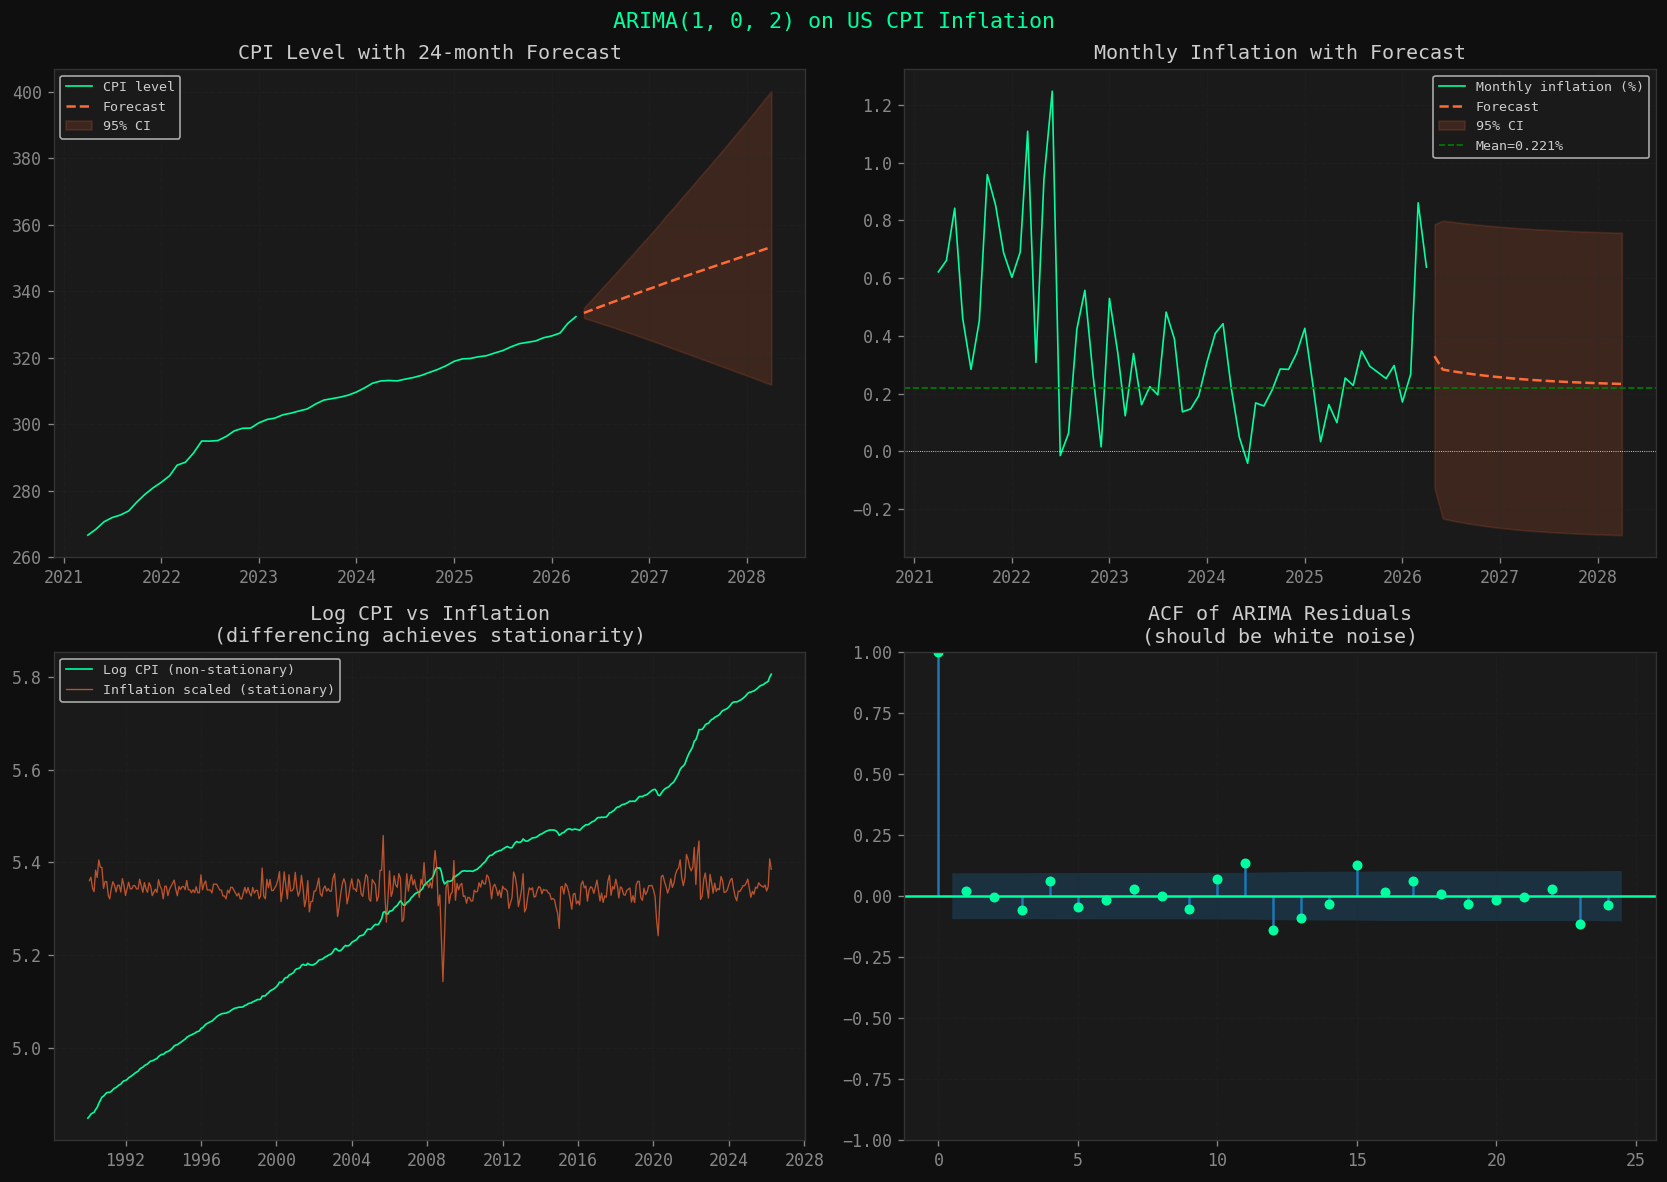

In [7]:
# --- ARIMA on CPI ---

# 2. Transformations
cpi_log    = np.log(cpi)                          # log level
inflation  = cpi_log.diff().dropna() * 100        # monthly inflation rate (%)
d_inflation = inflation.diff().dropna()           # change in inflation

# 3. Stationarity tests
def adf_test(series, name):
    stat, p, _, _, _, _ = adfuller(series.dropna())
    print(f'{name:30s}: ADF stat={stat:.3f}, p={p:.4f} --> {"STATIONARY" if p < 0.05 else "NON-STATIONARY"}')

print('\n--- Stationarity tests ---')
adf_test(cpi_log,     'Log CPI (level)')
adf_test(inflation,   'Monthly inflation (1st diff)')
adf_test(d_inflation, 'Change in inflation (2nd diff)')

# 4. auto_arima on inflation (1st difference)
print('\n--- auto_arima on monthly inflation ---')
auto_cpi = auto_arima(
    inflation,
    d=0,
    max_p=3, max_q=3,
    seasonal=True, m=12,  # monthly data with yearly seasonality
    max_P=2, max_Q=2,    # seasonal AR and MA orders
    information_criterion='aic',
    stepwise=True,
    trace=True,
    suppress_warnings=True
)
print(f'\nSelected order: ARIMA{auto_cpi.order}')

# 5. Refit with statsmodels
best_order_cpi = auto_cpi.order
cpi_model      = ARIMA(inflation, order=best_order_cpi).fit()
print(cpi_model.summary())

# 6. Forecast 24 months ahead
n_fc      = 24
fc_cpi    = cpi_model.forecast(steps=n_fc)
conf_cpi  = cpi_model.get_forecast(steps=n_fc).conf_int()
fc_index  = pd.date_range(inflation.index[-1], periods=n_fc+1, freq='MS')[1:]

# 7. Reconstruct CPI level forecast from inflation forecast
last_log_cpi   = cpi_log.iloc[-1]
log_cpi_fc     = last_log_cpi + np.cumsum(fc_cpi.values / 100)
log_cpi_fc_lo  = last_log_cpi + np.cumsum(conf_cpi.iloc[:,0].values / 100)
log_cpi_fc_hi  = last_log_cpi + np.cumsum(conf_cpi.iloc[:,1].values / 100)
cpi_fc         = np.exp(log_cpi_fc)
cpi_fc_lo      = np.exp(log_cpi_fc_lo)
cpi_fc_hi      = np.exp(log_cpi_fc_hi)

print(f'\nImplied annual inflation forecast (next 12m): '
      f'{((cpi_fc[11]/cpi.iloc[-1])-1)*100:.2f}%')

# 8. Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'ARIMA{best_order_cpi} on US CPI Inflation', fontsize=13, color=ACCENT)

# Panel 1: CPI level with forecast
axes[0,0].plot(cpi.iloc[-60:],  color=ACCENT,  lw=1,   label='CPI level')
axes[0,0].plot(fc_index, cpi_fc, color=ACCENT2, lw=1.5, ls='--', label='Forecast')
axes[0,0].fill_between(fc_index, cpi_fc_lo, cpi_fc_hi,
                        color=ACCENT2, alpha=0.15, label='95% CI')
axes[0,0].set_title('CPI Level with 24-month Forecast')
axes[0,0].legend(fontsize=8)
axes[0,0].grid(True, alpha=0.3)

# Panel 2: monthly inflation with forecast
axes[0,1].plot(inflation.iloc[-60:], color=ACCENT,  lw=1,   label='Monthly inflation (%)')
axes[0,1].plot(fc_index, fc_cpi,     color=ACCENT2, lw=1.5, ls='--', label='Forecast')
axes[0,1].fill_between(fc_index, conf_cpi.iloc[:,0], conf_cpi.iloc[:,1],
                        color=ACCENT2, alpha=0.15, label='95% CI')
axes[0,1].axhline(0, color='white', lw=0.5, ls=':')
axes[0,1].axhline(inflation.mean(), color='green', lw=1, ls='--',
                   label=f'Mean={inflation.mean():.3f}%')
axes[0,1].set_title('Monthly Inflation with Forecast')
axes[0,1].legend(fontsize=8)
axes[0,1].grid(True, alpha=0.3)

# Panel 3: stationarity illustration
axes[1,0].plot(cpi_log,     color=ACCENT,  lw=1,   label='Log CPI (non-stationary)')
axes[1,0].plot(inflation/10 + cpi_log.mean(), 
               color=ACCENT2, lw=0.8, alpha=0.7, label='Inflation scaled (stationary)')
axes[1,0].set_title('Log CPI vs Inflation\n(differencing achieves stationarity)')
axes[1,0].legend(fontsize=8)
axes[1,0].grid(True, alpha=0.3)

# Panel 4: ACF of residuals
residuals_cpi = cpi_model.resid
plot_acf(residuals_cpi, lags=24, ax=axes[1,1], color=ACCENT)
axes[1,1].set_title('ACF of ARIMA Residuals\n(should be white noise)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
print('AR coefficients  :', cpi_model.arparams)
print('MA coefficients  :', cpi_model.maparams)
print('Seasonal MA      :', cpi_model.seasonalmaparams)
print('Intercept        :', cpi_model.params.iloc[0])
print(f'Implied annual inflation: {cpi_model.params.iloc[0]*12:.2f}%')
print(f'AIC: {cpi_model.aic:.2f}')
print(f'BIC: {cpi_model.bic:.2f}')

AR coefficients  : [0.91693023]
MA coefficients  : [-0.39393322 -0.39974491]
Seasonal MA      : []
Intercept        : 0.2246888061140057
Implied annual inflation: 2.70%
AIC: -20.75
BIC: -0.39


---
## Part 7: Conditional Heteroskedasticity

### ARCH vs GARCH

**ARCH(q)** (Engle 1982) was the first model for time-varying volatility. 
The conditional variance depends only on past squared residuals:

$$\sigma_t^2 = \omega + \alpha_1 \varepsilon_{t-1}^2 + \cdots + \alpha_q \varepsilon_{t-q}^2$$

To capture persistent volatility you need large $q$, which means many 
parameters and unstable estimation.

**GARCH(p,q)** (Bollerslev 1986) generalizes ARCH by adding lagged 
conditional variances:

$$\sigma_t^2 = \omega + \sum_{i=1}^q \alpha_i \varepsilon_{t-i}^2 + \sum_{j=1}^p \beta_j \sigma_{t-j}^2$$

The $\beta_j \sigma_{t-j}^2$ terms act as an infinite distributed lag of 
past squared residuals, capturing long persistence with far fewer parameters. 
GARCH(1,1) with just three parameters $(\omega, \alpha, \beta)$ fits most 
financial series better than ARCH(10) or ARCH(20).

The relationship between ARCH and GARCH is exactly analogous to AR and ARMA:

<small> 

| Volatility model | Mean model | Parameters needed for persistence |
|---|---|---|
| ARCH(q) | AR(p) | Many: one per lag |
| GARCH(p,q) | ARMA(p,q) | Few: lagged variance absorbs history |

</small> 


Just as ARMA adds MA terms to AR to capture dynamics parsimoniously, 
GARCH adds lagged variance terms to ARCH. In both cases the generalization 
captures the same dynamics with dramatically fewer parameters.


## 7.1. GARCH(p,q) — Generalized Autoregressive Conditional Heteroskedasticity

### Motivation: volatility clustering

Although returns $r_t$ are approximately white noise, their **squares** $r_t^2$ are strongly autocorrelated. Large moves tend to cluster. This is called **volatility clustering** and it violates the homoskedasticity assumption of ARMA.

### Definition: GARCH(1,1)

$$r_t = \mu + \varepsilon_t, \qquad \varepsilon_t = \sigma_t z_t, \qquad z_t \sim IID(0,1)$$

$$\sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2$$

where:
- $\omega > 0$: baseline variance
- $\alpha \geq 0$: reaction to shocks (ARCH term)
- $\beta \geq 0$: persistence of volatility (GARCH term)
- $\alpha + \beta < 1$: stationarity condition

### Moments

$$\mathbb{E}[\varepsilon_t^2] = \frac{\omega}{1 - \alpha - \beta} =: \bar{\sigma}^2 \quad \text{(unconditional variance)}$$

$$\text{Cov}(\varepsilon_t^2, \varepsilon_{t-h}^2) > 0 \text{ for all } h > 0$$

The **half-life of volatility shocks**: $h_{1/2} = -\frac{\ln 2}{\ln(\alpha + \beta)}$



### Finance applications

- **VaR**: $\text{VaR}_{t+1} = \mu - z_{0.99} \cdot \hat{\sigma}_{t+1}$, 
  the maximum loss at a given confidence level given tomorrow's conditional volatility
- **Option pricing**: GARCH option pricing models (Duan 1995), where the 
  risk-neutral measure is derived from the GARCH dynamics
- **Risk management**: dynamic volatility estimates for position sizing, 
  scaling exposure inversely to $\hat{\sigma}_t$ so risk is constant over time

In [14]:
def fit_garch(returns, p=1, q=1, dist='t', scale=100):
    """
    Fit GARCH(p,q) model and return fitted model plus key risk metrics.
    
    Parameters
    ----------
    returns  : pd.Series of log returns
    p        : GARCH lag order (lagged variance terms)
    q        : ARCH lag order (lagged squared residual terms)
    dist     : innovation distribution: 'normal', 't', 'skewt'
    scale    : multiply returns by this before fitting (arch library 
               works better with returns in % rather than decimals)
    
    Returns
    -------
    model    : fitted arch model
    cond_vol : conditional volatility in original scale (not %)
    var_99   : 99% 1-day VaR in original scale (positive number = loss)
    var_95   : 95% 1-day VaR in original scale
    summary  : dict of key metrics
    """
    from arch import arch_model
    from scipy.stats import norm

    r_scaled = returns * scale

    garch = arch_model(
        r_scaled,
        vol='Garch',
        p=p, q=q,
        mean='Constant',
        dist=dist
    )
    model = garch.fit(disp='off')

    # conditional volatility back to original scale
    cond_vol = model.conditional_volatility / scale

    # annualized conditional volatility
    cond_vol_ann = cond_vol * np.sqrt(252)

    # parameters
    omega   = model.params['omega']
    alpha   = model.params[f'alpha[1]']
    beta    = model.params[f'beta[1]']
    mu      = model.params['mu'] / scale
    persist = alpha + beta
    hl      = -np.log(2) / np.log(persist)
    unc_vol = np.sqrt(omega / (1 - persist)) / scale

    # VaR: next day forecast
    fc          = model.forecast(horizon=1)
    sigma_next  = np.sqrt(fc.variance.iloc[-1, 0]) / scale

    # quantiles depend on distribution
    if dist == 'normal':
        z_99, z_95 = norm.ppf(0.01), norm.ppf(0.05)
    else:
        # use empirical quantiles of standardized residuals
        std_resid = model.std_resid
        z_99 = np.percentile(std_resid, 1)
        z_95 = np.percentile(std_resid, 5)

    var_99 = -(mu + z_99 * sigma_next)   # positive = loss
    var_95 = -(mu + z_95 * sigma_next)

    summary = {
        'omega'          : omega,
        'alpha'          : alpha,
        'beta'           : beta,
        'persistence'    : persist,
        'half_life_days' : hl,
        'uncond_vol_ann' : unc_vol * np.sqrt(252),
        'sigma_next'     : sigma_next,
        'sigma_next_ann' : sigma_next * np.sqrt(252),
        'VaR_99_1day'    : var_99,
        'VaR_95_1day'    : var_95,
        'AIC'            : model.aic,
        'BIC'            : model.bic,
        'log_lik'        : model.loglikelihood
    }

    return model, cond_vol, cond_vol_ann, var_99, var_95, summary

def plot_garch(returns, model, cond_vol, cond_vol_ann, var_99, var_95, 
               summary, title='GARCH(1,1)'):
    """
    Standard 4-panel GARCH diagnostic plot.
    
    Panels:
    1. Returns with conditional volatility bands
    2. Annualized conditional volatility over time
    3. VaR backtest: actual returns vs VaR estimates
    4. Standardized residuals ACF (should be white noise)
    """
    from statsmodels.graphics.tsaplots import plot_acf

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(title, fontsize=13, color=ACCENT)

    idx = returns.index[-len(cond_vol):]

    # Panel 1: returns with +/- 2 conditional vol bands
    axes[0,0].plot(idx, returns.iloc[-len(cond_vol):],
                   color='white', lw=0.4, alpha=0.6, label='Returns')
    axes[0,0].plot(idx,  2*cond_vol, color=ACCENT,  lw=1, label='+2 cond. vol')
    axes[0,0].plot(idx, -2*cond_vol, color=ACCENT,  lw=1, label='-2 cond. vol')
    axes[0,0].set_title('Returns with Conditional Volatility Bands')
    axes[0,0].legend(fontsize=8)
    axes[0,0].grid(True, alpha=0.3)

    # Panel 2: annualized conditional volatility
    axes[0,1].plot(idx, cond_vol_ann * 100, color=ACCENT2, lw=1)
    axes[0,1].axhline(summary['uncond_vol_ann']*100, color='white',
                       lw=1, ls='--', 
                       label=f'Unconditional vol: {summary["uncond_vol_ann"]*100:.1f}%')
    axes[0,1].set_title('Annualized Conditional Volatility (%)')
    axes[0,1].legend(fontsize=8)
    axes[0,1].grid(True, alpha=0.3)

    # Panel 3: VaR backtest
    r_plot   = returns.iloc[-len(cond_vol):]
    var_99_s = -(returns.mean() + 
                 np.percentile(model.std_resid, 1) * cond_vol.values)
    var_95_s = -(returns.mean() + 
                 np.percentile(model.std_resid, 5) * cond_vol.values)

    breaches_99 = r_plot.values < -var_99_s
    breaches_95 = r_plot.values < -var_95_s

    axes[1,0].plot(idx, r_plot.values, color='white', lw=0.4, alpha=0.5,
                   label='Returns')
    axes[1,0].plot(idx, -var_99_s, color='red',    lw=1, label='99% VaR')
    axes[1,0].plot(idx, -var_95_s, color='orange', lw=1, label='95% VaR')
    axes[1,0].scatter(idx[breaches_99], r_plot.values[breaches_99],
                      color='red', s=10, zorder=5, label=f'99% breaches: {breaches_99.sum()}')
    axes[1,0].scatter(idx[breaches_95], r_plot.values[breaches_95],
                      color='orange', s=6, zorder=4, label=f'95% breaches: {breaches_95.sum()}')
    axes[1,0].set_title('VaR Backtest')
    axes[1,0].legend(fontsize=7)
    axes[1,0].grid(True, alpha=0.3)

    # Panel 4: ACF of standardized residuals
    plot_acf(model.std_resid**2, lags=30, ax=axes[1,1], color=ACCENT)
    axes[1,1].set_title('ACF of Squared Standardized Residuals\n(should be white noise)')
    axes[1,1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # print summary
    print(f'\n--- {title} Summary ---')
    print(f'omega              : {summary["omega"]:.6f}')
    print(f'alpha (ARCH)       : {summary["alpha"]:.4f}')
    print(f'beta  (GARCH)      : {summary["beta"]:.4f}')
    print(f'Persistence        : {summary["persistence"]:.4f}')
    print(f'Half-life          : {summary["half_life_days"]:.1f} days')
    print(f'Unconditional vol  : {summary["uncond_vol_ann"]*100:.2f}% annualized')
    print(f'Next day sigma     : {summary["sigma_next_ann"]*100:.2f}% annualized')
    print(f'99% 1-day VaR      : {summary["VaR_99_1day"]*100:.3f}%')
    print(f'95% 1-day VaR      : {summary["VaR_95_1day"]*100:.3f}%')
    print(f'AIC                : {summary["AIC"]:.2f}')

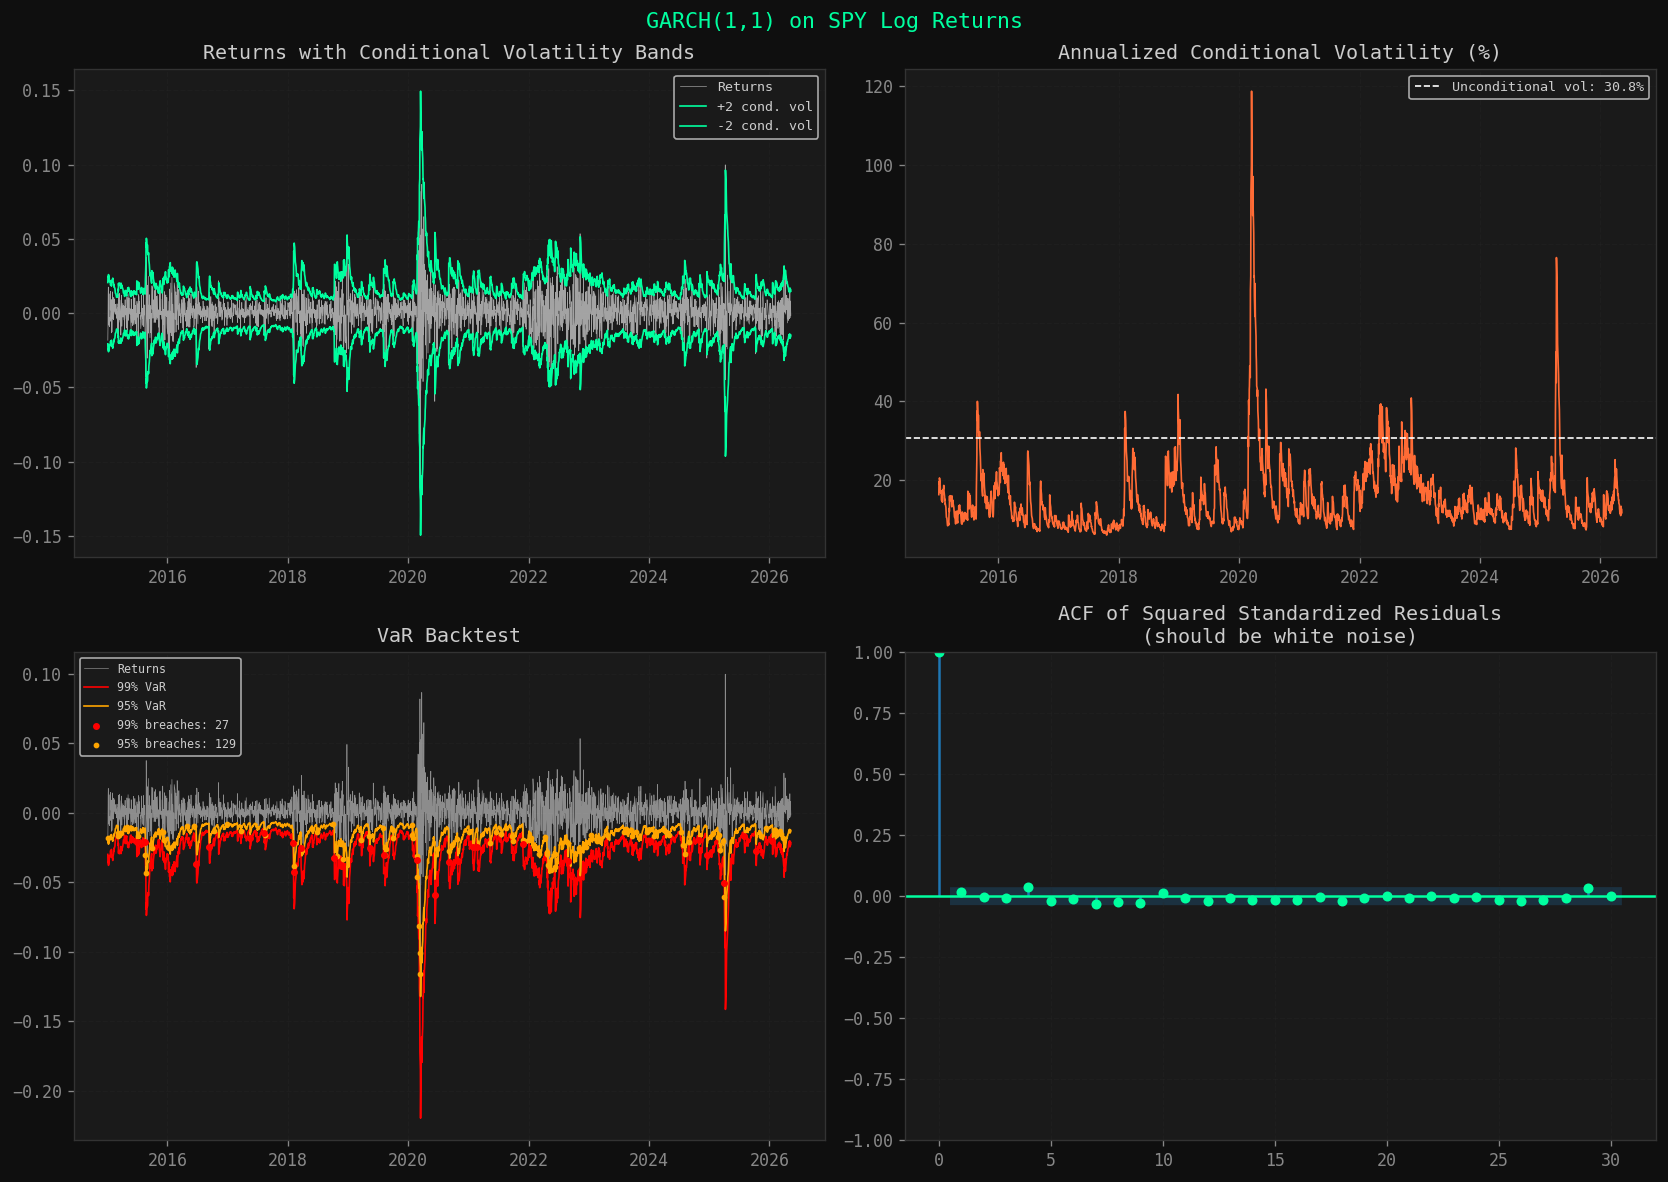


--- GARCH(1,1) on SPY Log Returns Summary ---
omega              : 0.022261
alpha (ARCH)       : 0.1701
beta  (GARCH)      : 0.8240
Persistence        : 0.9941
Half-life          : 116.5 days
Unconditional vol  : 30.75% annualized
Next day sigma     : 11.09% annualized
99% 1-day VaR      : 1.958%
95% 1-day VaR      : 1.139%
AIC                : 7164.35


In [15]:
# --- Example: fit on SPY returns ---
model, cond_vol, cond_vol_ann, var_99, var_95, summary = fit_garch(
    returns, p=1, q=1, dist='t')

plot_garch(returns, model, cond_vol, cond_vol_ann, var_99, var_95,
           summary, title='GARCH(1,1) on SPY Log Returns')

**GARCH(1,1) results: SPY 2015-2026.**

The fitted parameters $\alpha = 0.170$ and $\beta = 0.824$ are typical 
for equity indices, with a high persistence of $0.994$ implying a 
half-life of 116 trading days. A volatility shock takes roughly 6 months 
to decay by half, consistent with the long memory of equity volatility 
documented in the literature.

The unconditional volatility of $30.75\%$ annualized is elevated relative 
to the historical S\&P 500 average of 15-18\%, reflecting the inclusion of 
three major stress episodes in the sample: the Covid crash (2020), the rate 
shock (2022), and the tariff uncertainty episode (2025), all of which pulled 
the long-run variance estimate upward.

The current conditional volatility of $11.09\%$ annualized signals a calm 
regime as of May 2026, translating into a 99\% 1-day VaR of $1.96\%$ and 
a 95\% 1-day VaR of $1.14\%$. On a \$1M position this implies a maximum 
expected daily loss of \$19,580 at the 99\% confidence level under current 
market conditions. During the Covid spike the conditional VaR would have 
been 5-8x larger, illustrating the key advantage of GARCH over static 
historical VaR: the risk estimate adapts dynamically to the current 
volatility regime.